# Satella — Scoring Pipeline

Mövcud feature pipeline-ının üstünə qurulur:
1. OSM-dən **aptek + market** feature-ləri
2. **H3 hexagon** aqreqasiyası
3. İzahlı **Opportunity Score**
4. İnteraktiv **Bakı xəritəsi**

Hər hüceyrəni sırayla işlət. Çəkiləri (CELL 6) validasiya müsahibələrindən dəqiqləşdir.

In [ ]:
# =====================================================================
# SATELLA — SCORING PIPELINE (Colab notebook, tək fayl kimi)
# =====================================================================
# Bu skript sənin mövcud pipeline-ının ÜSTÜNƏ qurulur:
#   1) OSM-dən APTEK + MARKET POI feature-lərini əlavə edir
#   2) Nöqtələri H3 HEXAGON şəbəkəsinə toplayır (aggregate)
#   3) İzahlı OPPORTUNITY SCORE hesablayır (kateqoriya üzrə çəkilərlə)
#   4) İnteraktiv Bakı XƏRİTƏSİ çəkir
#
# Colab-da hər bloku ayrıca hüceyrəyə köçür (

In [ ]:
# ---- CELL ---- ayırıcıları)
# =====================================================================


In [2]:
# ---- CELL 1: Kitabxanalar ----
# Colab-da bir dəfə işlət
!pip install h3 pyrosm geopandas folium branca --quiet

import numpy as np
import pandas as pd
import geopandas as gpd
import h3
import folium
import branca.colormap as cm
from scipy.spatial import cKDTree

METRIC_CRS = "EPSG:3857"   # metrik (məsafə metrlə)
WGS84 = "EPSG:4326"        # coğrafi (lat/lon, H3 və xəritə üçün)



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# ---- CELL 2: APTEK + MARKET POI-lərini OSM-dən çıxar ----
# Bu addım sənin mövcud feature faylında OLMAYAN kateqoriyaları əlavə edir.
# Sənin əvvəl işlətdiyin .pbf faylı Colab-da olmalıdır.
from pyrosm import OSM

osm = OSM("azerbaijan-260701.osm.pbf")
pois = osm.get_pois()
pois = pois.to_crs(METRIC_CRS)

# OSM teqləri: aptek = amenity=pharmacy, market = shop=supermarket/convenience
pharmacies = pois[pois["amenity"] == "pharmacy"].copy()

# 'shop' sütunu bəzən ayrıca gəlir; yoxla və birləşdir
if "shop" in pois.columns:
    supermarkets = pois[pois["shop"].isin(["supermarket", "convenience"])].copy()
else:
    supermarkets = pois.iloc[0:0].copy()  # boş, əgər shop teqi yoxdursa

print("Aptek sayı:", len(pharmacies))
print("Market sayı:", len(supermarkets))

# Poligonları centroid-ə çevir (cKDTree yalnız nöqtə ilə işləyir)
for g in (pharmacies, supermarkets):
    g["geometry"] = g.geometry.centroid


Aptek sayı: 954
Market sayı: 6136


In [4]:
!pip install pyarrow



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# ---- CELL 3: Mövcud feature faylını yüklə ----
# Sənin əvvəlki notebook-un çıxışı
grid = gpd.read_parquet("Satella_final_features.parquet")
# Əgər csv-dirsə:
# import geopandas as gpd; from shapely import wkt
# df = pd.read_csv("/content/Satella_final_features.csv")
# df["geometry"] = df["geometry"].apply(wkt.loads)
# grid = gpd.GeoDataFrame(df, geometry="geometry", crs=METRIC_CRS)

# CRS-i təsdiqlə
if grid.crs is None:
    grid = grid.set_crs(METRIC_CRS)
grid = grid.to_crs(METRIC_CRS)
print("Grid nöqtə sayı:", len(grid))


Grid nöqtə sayı: 1685745


In [6]:
# ---- CELL 4: Aptek + market feature-lərini hesabla ----
# Sənin restoran üçün etdiyin EYNI məntiq: ən yaxın məsafə + 500m sıxlıq
grid_xy = np.column_stack([grid.geometry.x.values, grid.geometry.y.values])

def add_poi_features(grid, poi_gdf, name, radius=500):
    """Bir POI növü üçün ən yaxın məsafə və radius sıxlığı əlavə edir."""
    if len(poi_gdf) == 0:
        grid[f"dist_{name}"] = np.nan
        grid[f"{name}_500m"] = 0
        print(f"XƏBƏRDARLIQ: {name} üçün POI tapılmadı")
        return grid
    poi_xy = np.column_stack([poi_gdf.geometry.x.values, poi_gdf.geometry.y.values])
    tree = cKDTree(poi_xy)
    grid[f"dist_{name}"], _ = tree.query(grid_xy)
    grid[f"{name}_500m"] = tree.query_ball_point(grid_xy, r=radius, return_length=True)
    return grid

grid = add_poi_features(grid, pharmacies, "pharmacy")
grid = add_poi_features(grid, supermarkets, "supermarket")

print(grid[["dist_pharmacy", "pharmacy_500m", "dist_supermarket", "supermarket_500m"]].describe())


       dist_pharmacy  pharmacy_500m  dist_supermarket  supermarket_500m
count   1.685745e+06   1.685745e+06      1.685745e+06      1.685745e+06
mean    1.713483e+04   3.891158e-02      7.294615e+03      2.479966e-01
std     1.572119e+04   3.449131e-01      7.702376e+03      1.198917e+00
min     1.801027e+00   0.000000e+00      1.543520e+00      0.000000e+00
25%     5.081236e+03   0.000000e+00      1.585356e+03      0.000000e+00
50%     1.276783e+04   0.000000e+00      4.990707e+03      0.000000e+00
75%     2.443193e+04   0.000000e+00      1.042811e+04      0.000000e+00
max     1.219747e+05   1.600000e+01      8.221623e+04      3.200000e+01


In [7]:
# ---- CELL 5 (YENİLƏNMİŞ): Hexagon aqreqasiyası — restoran daxil ----
# Restoran feature-ləri (dist_restaurant, restaurants_500m) də əlavə olundu.

# Əvvəl grid-də hansı sütunlar var yoxla
rest_cols = [c for c in grid.columns if 'rest' in c.lower()]
print("Grid-də restoran sütunları:", rest_cols)

H3_RES = 9
grid_wgs = grid.to_crs(WGS84)
grid["lat"] = grid_wgs.geometry.y.values
grid["lon"] = grid_wgs.geometry.x.values
grid["h3"] = [h3.latlng_to_cell(lat, lon, H3_RES)
              for lat, lon in zip(grid["lat"], grid["lon"])]

# Aqreqasiya lüğəti — restoran da daxil
agg_dict = {
    "population":       ("population", "sum"),
    "dist_pharmacy":    ("dist_pharmacy", "mean"),
    "dist_supermarket": ("dist_supermarket", "mean"),
    "dist_restaurant":  ("dist_restaurant", "mean"),      # RESTORAN
    "dist_bank":        ("dist_bank", "mean"),
    "pharmacy_500m":    ("pharmacy_500m", "mean"),
    "supermarket_500m": ("supermarket_500m", "mean"),
    "restaurants_500m": ("restaurants_500m", "mean"),      # RESTORAN (diqqət: adı cəm)
    "buildings_500m":   ("buildings_500m", "mean"),
    "roads_300m":       ("roads_300m", "mean"),
    "n_points":         ("population", "size"),
}

# Yalnız grid-də mövcud olan sütunları saxla (xəta qarşısı)
agg_dict = {k: v for k, v in agg_dict.items() if v[0] in grid.columns}
print("Aqreqasiya olunan sütunlar:", list(agg_dict.keys()))

agg = grid.groupby("h3").agg(**agg_dict).reset_index()

# DİQQƏT: restoran sütununun adı. compute_score "restaurant_500m" gözləyir,
# amma ilk notebook "restaurants_500m" (cəm) yaratmışdı. Uyğunlaşdır:
if "restaurants_500m" in agg.columns and "restaurant_500m" not in agg.columns:
    agg["restaurant_500m"] = agg["restaurants_500m"]

print("\nHexagon sayı:", len(agg))
print("agg sütunları:", list(agg.columns))

Grid-də restoran sütunları: ['dist_restaurant', 'restaurants_500m']
Aqreqasiya olunan sütunlar: ['population', 'dist_pharmacy', 'dist_supermarket', 'dist_restaurant', 'dist_bank', 'pharmacy_500m', 'supermarket_500m', 'restaurants_500m', 'buildings_500m', 'roads_300m', 'n_points']

Hexagon sayı: 174531
agg sütunları: ['h3', 'population', 'dist_pharmacy', 'dist_supermarket', 'dist_restaurant', 'dist_bank', 'pharmacy_500m', 'supermarket_500m', 'restaurants_500m', 'buildings_500m', 'roads_300m', 'n_points', 'restaurant_500m']


In [8]:
# ---- CELL 6: OPPORTUNITY SCORE (izahlı, çəki-əsaslı) ----
# PRİNSİP: hər feature-i 0-1 aralığına normallaşdırırıq, sonra çəki ilə birləşdiririk.
# Çəkilər KONFIQURASIYADADIR — koda sərt yazılmayıb, ki asan dəyişəsən.

def normalize(series, invert=False):
    med = series.median()
    if pd.isna(med):
        med = 0
    s = series.fillna(med)
    lo, hi = s.quantile(0.02), s.quantile(0.98)   # tavan yumşaldıldı (95→98), az hexagon tavana yığılır
    if hi == lo:
        return pd.Series(0.5, index=s.index)
    norm = ((s - lo) / (hi - lo)).clip(0, 1)
    return (1 - norm) if invert else norm

# --- Kateqoriya üzrə çəkilər (validasiya müsahibələrindən dəqiqləşdir) ---
WEIGHTS = {
    "pharmacy": {
        "population":      0.35,
        "low_competition": 0.30,
        "accessibility":   0.20,
        "urban_density":   0.15,
    },
    "supermarket": {
        "population":      0.30,
        "low_competition": 0.25,
        "accessibility":   0.25,
        "urban_density":   0.20,
    },
}

def compute_score(agg, category):
    w = WEIGHTS[category]
    comp_col = f"{category}_500m"      # rəqib sıxlığı (500m-də say)
    dist_col = f"dist_{category}"      # ən yaxın rəqibə məsafə

    f_pop  = normalize(agg["population"])          # çox əhali = yaxşı
    f_acc  = normalize(agg["roads_300m"])          # çox yol = əlçatan
    f_dens = normalize(agg["buildings_500m"])      # çox bina = canlı

    # --- Rəqib komponenti: məsafə + say birləşməsi ---
    # DÜZƏLİŞ: aptek sıxlığı çox seyrəkdir (əksər hexagonda 0), tək başına
    # ayırdetmə vermir. Məsafə zəngin siqnaldır (hər hexagonda fərqli).
    f_comp_dist  = normalize(agg[dist_col])                 # uzaq rəqib = yaxşı (invert YOX)
    f_comp_count = normalize(agg[comp_col], invert=True)    # az say = yaxşı
    f_comp = f_comp_dist * 0.6 + f_comp_count * 0.4         # məsafəyə çox çəki

    score = (
        w["population"]      * f_pop  +
        w["low_competition"] * f_comp +
        w["accessibility"]   * f_acc  +
        w["urban_density"]   * f_dens
    ) * 100

    out = agg.copy()
    out["score"] = score.round(1)
    out["c_population"]      = (f_pop  * 100).round(0)
    out["c_low_competition"] = (f_comp * 100).round(0)
    out["c_accessibility"]   = (f_acc  * 100).round(0)
    out["c_urban_density"]   = (f_dens * 100).round(0)
    return out

CATEGORY = "pharmacy"
scored = compute_score(agg, CATEGORY)

# Ayırdetməni yoxla: neçə fərqli bal var, paylanma necədir
print("Fərqli bal sayı:", scored["score"].nunique())
print("\nBal paylanması:")
print(scored["score"].describe())
print("\nTop 10:")
print(scored[["h3", "score", "c_population", "c_low_competition",
              "c_accessibility", "c_urban_density"]].sort_values("score", ascending=False).head(10))

Fərqli bal sayı: 834

Bal paylanması:
count    174531.000000
mean         24.212975
std          11.390190
min           0.500000
25%          16.900000
50%          20.900000
75%          27.400000
max         100.000000
Name: score, dtype: float64

Top 10:
                    h3  score  c_population  c_low_competition  \
89455  892c0ba4ddbffff  100.0         100.0              100.0   
89451  892c0ba4dcbffff   99.6          99.0              100.0   
89395  892c0ba4c37ffff   99.2          98.0              100.0   
92914  892c0bd1473ffff   94.5         100.0               82.0   
92915  892c0bd1477ffff   94.4         100.0               81.0   
92892  892c0bd140fffff   93.0          96.0               81.0   
92910  892c0bd1463ffff   92.9          95.0               82.0   
89391  892c0ba4c27ffff   91.8          84.0              100.0   
89453  892c0ba4dd3ffff   91.6          81.0              100.0   
92916  892c0bd147bffff   90.9          89.0               82.0   

       c_acces

In [9]:
# ---- CELL 7: Bakı ilə məhdudlaş + boş hexagonları at ----
# Az əhalili/boş hexagonlar mənasız tövsiyə verir, onları çıxar
scored = scored[scored["n_points"] >= 3]            # ən azı 3 nöqtəli hexagon
scored = scored[scored["population"] >= 5]          # minimal əhali həddi

# Bakı bbox (təxmini, lat/lon) — öz sərhədinə görə dəqiqləşdir
BAKU = {"lat_min": 40.30, "lat_max": 40.50, "lon_min": 49.75, "lon_max": 50.05}

def h3_center(h):
    lat, lon = h3.cell_to_latlng(h)
    return pd.Series({"h_lat": lat, "h_lon": lon})

centers = scored["h3"].apply(h3_center)
scored = pd.concat([scored, centers], axis=1)
baku = scored[
    (scored["h_lat"].between(BAKU["lat_min"], BAKU["lat_max"])) &
    (scored["h_lon"].between(BAKU["lon_min"], BAKU["lon_max"]))
].copy()
print("Bakı hexagon sayı:", len(baku))


Bakı hexagon sayı: 3505


In [10]:
# ---- CELL 8: İNTERAKTIV XƏRİTƏ ----
# Hər hexagonu skoruna görə rənglə + klikləyəndə izah göstər
m = folium.Map(location=[40.40, 49.87], zoom_start=12, tiles="cartodbpositron")

colormap = cm.LinearColormap(
    colors=["#C9D9EC", "#7FA8D4", "#1D9E75"],  # Satella brend: açıq mavi → yaşıl
    vmin=baku["score"].min(), vmax=baku["score"].max(),
    caption=f"Opportunity Score — {CATEGORY}"
)

for _, r in baku.iterrows():
    boundary = h3.cell_to_boundary(r["h3"])       # hexagon küncləri (lat,lon)
    popup = (f"<b>Score: {r['score']}</b><br>"
             f"Əhali: {int(r['population'])}<br>"
             f"Əhali balı: {int(r['c_population'])}<br>"
             f"Az rəqib balı: {int(r['c_low_competition'])}<br>"
             f"Əlçatanlıq balı: {int(r['c_accessibility'])}<br>"
             f"Sıxlıq balı: {int(r['c_urban_density'])}")
    folium.Polygon(
        locations=boundary,
        color=None, fill=True,
        fill_color=colormap(r["score"]),
        fill_opacity=0.6,
        popup=folium.Popup(popup, max_width=250),
    ).add_to(m)

colormap.add_to(m)
m.save("satella_baku_map.html")
m   # Colab-da birbaşa göstərir


In [20]:
# ---- CELL 9: Nəticəni saxla ----

baku.to_csv("satella_scored_baku.csv", index=False)
print("Saxlanıldı: satella_scored_baku.parquet / .csv / satella_baku_map.html")


Saxlanıldı: satella_scored_baku.parquet / .csv / satella_baku_map.html


In [11]:
!pip install --upgrade pandas pyarrow geopandas



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Mövcud aptek sayı: 954
Skorlanmış hexagona düşən aptek: 953
(Fərq = əhali həddindən aşağı / boş hexagona düşənlər)
BACKTESTING NƏTİCƏSİ
Bütün hexagonların orta balı:  24.2
Aptek olan hexagonların orta balı: 60.5
Fərq: +36.3 bal

Bütün hexagonların medianı:  20.9
Aptek hexagonlarının medianı: 68.2

Yuxarı 25% həddi (bal): 27.4
Yuxarı 25% zonada olan aptek faizi: 95%
(Təsadüf olsaydı ~25% gözlənilərdi. Yüksək faiz = model işləyir)
Apteklərin bal persentili (0-100, yüksək = yaxşı zona):
count    953.000000
mean      94.169021
std       14.646719
min        0.013751
25%       96.672224
50%       98.549828
75%       98.758960
max       98.758960
dtype: float64

Apteklərin 97%-i median üstü zonadadır
Apteklərin 95%-i yuxarı çərək zonadadır


Matplotlib is building the font cache; this may take a moment.


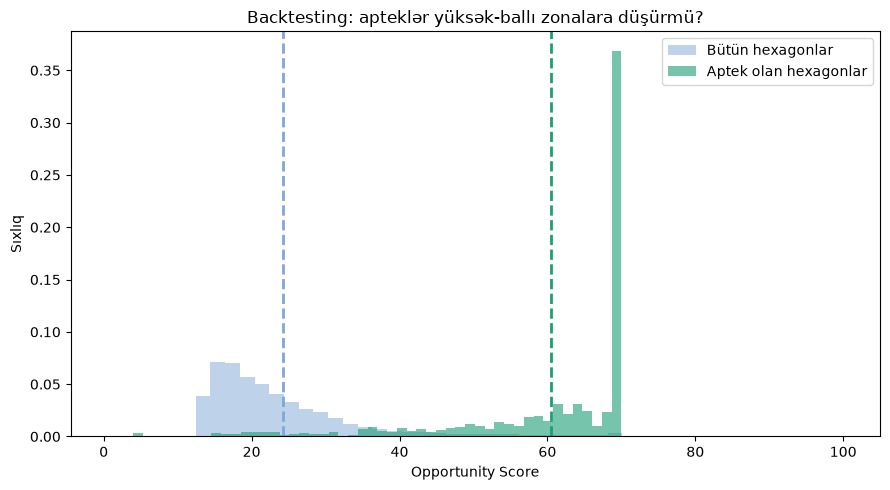

Əgər yaşıl (aptek) əyri mavidən (hamı) SAĞDA yığılıbsa → model işləyir


In [24]:
# =====================================================================
# SATELLA — BACKTESTING (mövcud pipeline-ın davamı)
# =====================================================================
# Sual: mövcud 954 aptek modelin YÜKSƏK bal verdiyi hexagonlara düşürmü?
# Əgər bəli → model real uğurlu qərarlarla üst-üstə düşür.
# QEYD: aptek yerlərini yalnız YOXLAMA üçün işlədirik, öyrətmə üçün YOX.
# =====================================================================


# ---- CELL 10: Hər mövcud apteki bir hexagona bağla ----
# pharmacies GeoDataFrame CELL 2-dən gəlir (metrik CRS-də)
ph_wgs = pharmacies.to_crs(WGS84)
ph_h3 = [h3.latlng_to_cell(geom.y, geom.x, H3_RES) for geom in ph_wgs.geometry]

# Skorlanmış hexagonları bir lüğətə çevir (sürətli axtarış üçün)
score_by_h3 = dict(zip(scored["h3"], scored["score"]))
# İzah komponentlərini də götür
comp_by_h3 = dict(zip(scored["h3"], scored["c_low_competition"]))

# Hər aptekin düşdüyü hexagonun balını tap
ph_scores = []
for h in ph_h3:
    if h in score_by_h3:
        ph_scores.append(score_by_h3[h])
ph_scores = pd.Series(ph_scores)

print(f"Mövcud aptek sayı: {len(ph_h3)}")
print(f"Skorlanmış hexagona düşən aptek: {len(ph_scores)}")
print(f"(Fərq = əhali həddindən aşağı / boş hexagona düşənlər)")


# ---- CELL 11: Müqayisə — apteklər vs bütün hexagonlar ----
# ƏSAS TEST: apteklərin ORTA balı, bütün hexagonların ORTA balından yüksəkdirmi?
all_scores = scored["score"]

print("="*55)
print("BACKTESTING NƏTİCƏSİ")
print("="*55)
print(f"Bütün hexagonların orta balı:  {all_scores.mean():.1f}")
print(f"Aptek olan hexagonların orta balı: {ph_scores.mean():.1f}")
print(f"Fərq: {ph_scores.mean() - all_scores.mean():+.1f} bal")
print()
print(f"Bütün hexagonların medianı:  {all_scores.median():.1f}")
print(f"Aptek hexagonlarının medianı: {ph_scores.median():.1f}")

# Apteklər neçə faiz halda yüksək-ballı zonadadır?
# "Yüksək" = bütün hexagonların yuxarı 25%-i
threshold = all_scores.quantile(0.75)
in_top = (ph_scores >= threshold).mean() * 100
print()
print(f"Yuxarı 25% həddi (bal): {threshold:.1f}")
print(f"Yuxarı 25% zonada olan aptek faizi: {in_top:.0f}%")
print(f"(Təsadüf olsaydı ~25% gözlənilərdi. Yüksək faiz = model işləyir)")


# ---- CELL 12: Persentil analizi — daha incə görünüş ----
# Hər aptek bütün hexagonlar arasında hansı persentildədir?
def to_percentile(val, dist):
    return (dist < val).mean() * 100

ph_percentiles = pd.Series([to_percentile(s, all_scores) for s in ph_scores])
print("Apteklərin bal persentili (0-100, yüksək = yaxşı zona):")
print(ph_percentiles.describe())
print()
print(f"Apteklərin {(ph_percentiles >= 50).mean()*100:.0f}%-i median üstü zonadadır")
print(f"Apteklərin {(ph_percentiles >= 75).mean()*100:.0f}%-i yuxarı çərək zonadadır")


# ---- CELL 13: Vizual — bal paylanması müqayisəsi ----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(all_scores, bins=50, alpha=0.5, label="Bütün hexagonlar", color="#7FA8D4", density=True)
ax.hist(ph_scores, bins=50, alpha=0.6, label="Aptek olan hexagonlar", color="#1D9E75", density=True)
ax.axvline(all_scores.mean(), color="#7FA8D4", linestyle="--", linewidth=2)
ax.axvline(ph_scores.mean(), color="#1D9E75", linestyle="--", linewidth=2)
ax.set_xlabel("Opportunity Score")
ax.set_ylabel("Sıxlıq")
ax.set_title("Backtesting: apteklər yüksək-ballı zonalara düşürmü?")
ax.legend()
plt.tight_layout()
plt.savefig("backtest_distribution.png", dpi=120)
plt.show()
print("Əgər yaşıl (aptek) əyri mavidən (hamı) SAĞDA yığılıbsa → model işləyir")

In [25]:
# Apteklərin "az rəqib" komponenti nə göstərir?
ph_comp = pd.Series([comp_by_h3[h] for h in ph_h3 if h in comp_by_h3])
print("Apteklərin 'az rəqib' balı:")
print(ph_comp.describe())
print(f"\nBütün hexagonların 'az rəqib' balı ortalaması: {scored['c_low_competition'].mean():.1f}")
print(f"Apteklərin 'az rəqib' balı ortalaması: {ph_comp.mean():.1f}")

Apteklərin 'az rəqib' balı:
count    953.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64

Bütün hexagonların 'az rəqib' balı ortalaması: 56.5
Apteklərin 'az rəqib' balı ortalaması: 0.0


In [26]:
# =====================================================================
# SATELLA — MARKET (SUPERMARKET) SKORLAMA + BACKTESTING
# =====================================================================
# DİQQƏT: bu, modeli market üçün YENİDƏN skorlayır, sonra market
# yerlərini yoxlayır. Aptek nəticələrini əvəz etmir — ayrı dəyişəndə saxlayır.
# Bütün backtest hüceyrələrini (CELL 10-13) işlətdikdən sonra bunu işlət.
# =====================================================================


# ---- CELL 14: Market üçün yenidən skorla ----
CATEGORY_M = "supermarket"
scored_m = compute_score(agg, CATEGORY_M)   # eyni funksiya, fərqli kateqoriya

# Bakı ilə məhdudlaş (CELL 7 ilə eyni məntiq)
scored_m = scored_m[scored_m["n_points"] >= 3]
scored_m = scored_m[scored_m["population"] >= 5]
centers_m = scored_m["h3"].apply(h3_center)
scored_m = pd.concat([scored_m, centers_m], axis=1)
baku_m = scored_m[
    (scored_m["h_lat"].between(BAKU["lat_min"], BAKU["lat_max"])) &
    (scored_m["h_lon"].between(BAKU["lon_min"], BAKU["lon_max"]))
].copy()

print("Market üçün skorlama tamam.")
print("Fərqli bal sayı:", scored_m["score"].nunique())
print("Bal paylanması:")
print(scored_m["score"].describe())


# ---- CELL 15: Market yerlərini hexagona bağla ----
# supermarkets GeoDataFrame CELL 2-dən gəlir
sm_wgs = supermarkets.to_crs(WGS84)
sm_h3 = [h3.latlng_to_cell(geom.y, geom.x, H3_RES) for geom in sm_wgs.geometry]

score_by_h3_m = dict(zip(scored_m["h3"], scored_m["score"]))
comp_by_h3_m  = dict(zip(scored_m["h3"], scored_m["c_low_competition"]))

sm_scores = pd.Series([score_by_h3_m[h] for h in sm_h3 if h in score_by_h3_m])
print(f"\nMövcud market sayı: {len(sm_h3)}")
print(f"Skorlanmış hexagona düşən market: {len(sm_scores)}")


# ---- CELL 16: Market backtesting nəticəsi ----
all_scores_m = scored_m["score"]

print("="*55)
print("MARKET BACKTESTING NƏTİCƏSİ")
print("="*55)
print(f"Bütün hexagonların orta balı:   {all_scores_m.mean():.1f}")
print(f"Market olan hexagonların orta balı: {sm_scores.mean():.1f}")
print(f"Fərq: {sm_scores.mean() - all_scores_m.mean():+.1f} bal")
print()
print(f"Bütün hexagonların medianı:   {all_scores_m.median():.1f}")
print(f"Market hexagonlarının medianı: {sm_scores.median():.1f}")

threshold_m = all_scores_m.quantile(0.75)
in_top_m = (sm_scores >= threshold_m).mean() * 100
print()
print(f"Yuxarı 25% həddi (bal): {threshold_m:.1f}")
print(f"Yuxarı 25% zonada olan market faizi: {in_top_m:.0f}%")
print(f"(Təsadüf olsaydı ~25% gözlənilərdi)")

# Fürsət yoxlaması — marketlərin 'az rəqib' balı
sm_comp = pd.Series([comp_by_h3_m[h] for h in sm_h3 if h in comp_by_h3_m])
print()
print(f"Bütün hexagonların 'az rəqib' balı ortalaması: {scored_m['c_low_competition'].mean():.1f}")
print(f"Marketlərin 'az rəqib' balı ortalaması: {sm_comp.mean():.1f}")
print("(Market balı aşağı olmalıdır — market olan yerdə rəqib var = fürsət deyil)")


# ---- CELL 17: Aptek vs Market müqayisəsi (xülasə) ----
print("="*55)
print("XÜLASƏ — İKİ KATEQORIYA")
print("="*55)
print(f"{'Metrika':<38}{'Aptek':>8}{'Market':>8}")
print("-"*54)
print(f"{'Mövcud obyekt sayı':<38}{len(ph_h3):>8}{len(sm_h3):>8}")
print(f"{'Orta bal (obyekt hexagonları)':<38}{ph_scores.mean():>8.1f}{sm_scores.mean():>8.1f}")
print(f"{'Orta bal (bütün hexagonlar)':<38}{all_scores.mean():>8.1f}{all_scores_m.mean():>8.1f}")
print(f"{'Yuxarı 25%-də olan obyekt faizi':<38}{(ph_scores >= all_scores.quantile(0.75)).mean()*100:>7.0f}%{in_top_m:>7.0f}%")

Market üçün skorlama tamam.
Fərqli bal sayı: 805
Bal paylanması:
count    100392.000000
mean         25.000412
std          13.271408
min           1.000000
25%          16.300000
50%          20.800000
75%          28.500000
max          92.100000
Name: score, dtype: float64

Mövcud market sayı: 6136
Skorlanmış hexagona düşən market: 6102
MARKET BACKTESTING NƏTİCƏSİ
Bütün hexagonların orta balı:   25.0
Market olan hexagonların orta balı: 56.5
Fərq: +31.5 bal

Bütün hexagonların medianı:   20.8
Market hexagonlarının medianı: 60.8

Yuxarı 25% həddi (bal): 28.5
Yuxarı 25% zonada olan market faizi: 89%
(Təsadüf olsaydı ~25% gözlənilərdi)

Bütün hexagonların 'az rəqib' balı ortalaması: 49.5
Marketlərin 'az rəqib' balı ortalaması: 2.7
(Market balı aşağı olmalıdır — market olan yerdə rəqib var = fürsət deyil)
XÜLASƏ — İKİ KATEQORIYA
Metrika                                  Aptek  Market
------------------------------------------------------
Mövcud obyekt sayı                         954    6

In [12]:
# =====================================================================
# SATELLA — MVP İSTİFADƏÇİ AXINI
# =====================================================================
# İstifadəçi seçir: kateqoriya + mərkəz POI (lat, lon) + radius (km)
# Sistem qaytarır: həmin dairə içində ən yüksək fürsətli zonalar
#
# PRİNSİP (danışdığımız arxitektura):
#  - Bütün hexagonlar ƏVVƏLCƏDƏN skorlanıb (serving qatı)
#  - Hər sorğuda yalnız SÜZÜB sıralayırıq (sürətli)
#  - Mərkəz POI = coğrafi mərkəz (rəqib yox, kannibalizasiya yox)
# =====================================================================


# ---- CELL 18: Bütün kateqoriyaları əvvəlcədən skorla (serving qatı) ----
# Hər kateqoriya üçün bir dəfə skorla, lüğətdə saxla.
# Real platformada bu, bazada saxlanılan "serving" cədvəlidir.
SERVING = {}
for cat in ["pharmacy", "supermarket"]:
    sc = compute_score(agg, cat)
    sc = sc[(sc["n_points"] >= 3) & (sc["population"] >= 5)].copy()
    # hexagon mərkəz koordinatlarını əlavə et (süzmə üçün lazım)
    centers = sc["h3"].apply(h3_center)
    sc = pd.concat([sc, centers], axis=1)
    SERVING[cat] = sc.reset_index(drop=True)
    print(f"{cat}: {len(sc)} skorlanmış hexagon hazır")


# ---- CELL 19: Əsas tövsiyə funksiyası ----
import math

def haversine_km(lat1, lon1, lat2, lon2):
    """İki nöqtə arası məsafə (km). Vektorlaşdırılmış (pandas seriyaları ilə işləyir)."""
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def recommend(category, center_lat, center_lon, radius_km=2.0,
              top_n=10, min_score=None):
    """
    Satella-nın əsas tövsiyə funksiyası.

    category    : "pharmacy" və ya "supermarket"
    center_lat/lon : mərkəz POI (istifadəçi seçir) — coğrafi mərkəz
    radius_km   : maraq sahəsinin radiusu (min/max ilə məhdudlaşdırılır)
    top_n       : neçə zona qaytarılsın
    min_score   : (opsional) yalnız bu baldan yüksək zonalar

    Qaytarır: sıralanmış tövsiyə cədvəli (ən yüksək bal əvvəldə)
    """
    # --- Radius həddləri (danışdığımız min/max qorunması) ---
    radius_km = max(0.5, min(radius_km, 10.0))   # 0.5-10 km arası

    if category not in SERVING:
        raise ValueError(f"Kateqoriya yoxdur: {category}. Mövcud: {list(SERVING)}")

    sc = SERVING[category]

    # --- 1) Sahəni süz: mərkəzdən radius içindəki hexagonlar ---
    dist = haversine_km(center_lat, center_lon, sc["h_lat"], sc["h_lon"])
    in_area = sc[dist <= radius_km].copy()
    in_area["dist_km"] = dist[dist <= radius_km].round(2)

    if len(in_area) == 0:
        print("Bu sahədə skorlanmış hexagon yoxdur. Radiusu artır və ya mərkəzi dəyiş.")
        return in_area

    # --- 2) (opsional) minimal bal həddi ---
    if min_score is not None:
        in_area = in_area[in_area["score"] >= min_score]

    # --- 3) Sırala: ən yüksək bal əvvəldə ---
    ranked = in_area.sort_values("score", ascending=False).head(top_n)

    # --- 4) İzahlı çıxış (explainability) ---
    cols = ["h3", "score", "dist_km", "population",
            "c_population", "c_low_competition", "c_accessibility", "c_urban_density"]
    return ranked[cols].reset_index(drop=True)


# ---- CELL 20: NÜMUNƏ İSTİFADƏ ----
# Bakının mərkəzi (Fəvvarələr meydanı təxmini) ətrafında aptek fürsəti
CENTER_LAT, CENTER_LON = 40.3725, 49.8375   # istifadəçi seçir
result = recommend("pharmacy", CENTER_LAT, CENTER_LON, radius_km=2.0, top_n=10)
print(f"Aptek tövsiyələri (mərkəzdən 2 km, top 10):\n")
print(result.to_string(index=False))


# ---- CELL 21: Nəticəni interaktiv xəritədə göstər ----
def show_recommendations(category, center_lat, center_lon, radius_km=2.0, top_n=10):
    result = recommend(category, center_lat, center_lon, radius_km, top_n)
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron")

    # Mərkəz POI-ni göstər
    folium.Marker([center_lat, center_lon], tooltip="Mərkəz POI",
                  icon=folium.Icon(color="blue", icon="star")).add_to(m)
    # Radius dairəsi
    folium.Circle([center_lat, center_lon], radius=radius_km*1000,
                  color="#185FA5", fill=False, weight=2, dash_array="5").add_to(m)

    # Tövsiyə olunan hexagonlar (yaşıl = yüksək fürsət)
    if len(result) > 0:
        cmap = cm.LinearColormap(["#C9D9EC", "#1D9E75"],
                                 vmin=result["score"].min(), vmax=result["score"].max())
        for rank, r in result.iterrows():
            boundary = h3.cell_to_boundary(r["h3"])
            popup = (f"<b>#{rank+1} — Score: {r['score']}</b><br>"
                     f"Mərkəzdən: {r['dist_km']} km<br>"
                     f"Əhali: {int(r['population'])}<br>"
                     f"Əhali balı: {int(r['c_population'])}<br>"
                     f"Az rəqib balı: {int(r['c_low_competition'])}<br>"
                     f"Əlçatanlıq: {int(r['c_accessibility'])}<br>"
                     f"Sıxlıq: {int(r['c_urban_density'])}")
            folium.Polygon(boundary, color="#1D9E75", weight=2,
                           fill=True, fill_color=cmap(r["score"]), fill_opacity=0.7,
                           popup=folium.Popup(popup, max_width=250)).add_to(m)
    return m

# Nümunə: aptek, mərkəzdən 2 km, top 10
show_recommendations("pharmacy", CENTER_LAT, CENTER_LON, radius_km=2.0, top_n=10)


# ---- CELL 22: Market üçün eyni axın ----
# Sadəcə kateqoriyanı dəyiş — funksiya eynidir
show_recommendations("supermarket", CENTER_LAT, CENTER_LON, radius_km=2.5, top_n=10)

pharmacy: 100392 skorlanmış hexagon hazır
supermarket: 100392 skorlanmış hexagon hazır
Aptek tövsiyələri (mərkəzdən 2 km, top 10):

             h3  score  dist_km  population  c_population  c_low_competition  c_accessibility  c_urban_density
892ce581813ffff   82.0     1.68 1066.787828         100.0               40.0            100.0            100.0
892ce581ccbffff   82.0     1.13 2082.215283         100.0               40.0            100.0            100.0
892ce581ed7ffff   80.3     1.89  678.731897         100.0               40.0             91.0            100.0
892ce581123ffff   70.0     1.43 2537.598920         100.0                0.0            100.0            100.0
892ce58026fffff   70.0     1.85 2543.962900         100.0                0.0            100.0            100.0
892ce581127ffff   70.0     1.10 2123.408770         100.0                0.0            100.0            100.0
892ce581133ffff   70.0     1.71 2382.679604         100.0                0.0            100

In [13]:
# ---- CELL 24: Kitabxanalar ----
!pip install rasterio --quiet
import rasterio
from rasterio.merge import merge
from rasterio.warp import transform as rio_transform
import glob
import numpy as np
import pandas as pd


# ---- CELL 25a: 4 tile-ı birləşdir (hər il üçün mozaika) ----
# Azərbaycan 4 tile-a düşür — onları bir bütöv rasterə birləşdiririk.

def build_mosaic(pattern, out_path):
    """Verilmiş şablona uyğun bütün tile-ları bir fayla birləşdirir."""
    files = sorted(glob.glob(pattern))
    if len(files) == 0:
        raise FileNotFoundError(f"Tile tapılmadı: {pattern}")
    print(f"{len(files)} tile tapıldı:")
    for f in files:
        print("   ", f.split("/")[-1])
    srcs = [rasterio.open(f) for f in files]
    mosaic, out_trans = merge(srcs)
    meta = srcs[0].meta.copy()
    meta.update({"height": mosaic.shape[1], "width": mosaic.shape[2],
                 "transform": out_trans})
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mosaic)
    for s in srcs:
        s.close()
    print(f"Birləşdirildi → {out_path}\n")
    return out_path

# Fayl adlarındakı ortaq hissəyə görə şablon.
# Əgər adların fərqlidirsə, yuxarıdakı glob çıxışına baxıb bu şablonları dəyiş.
GHSL_2015 = build_mosaic("*E2015*.tif", "mosaic_2015.tif")
GHSL_2020 = build_mosaic("*E2020*.tif", "mosaic_2020.tif")


# ---- CELL 25b: Birləşmiş rasterdən hexagon başına tikili sahə oxu ----
def sample_raster_at_hexagons(raster_path, hex_df, lat_col="h_lat", lon_col="h_lon"):
    with rasterio.open(raster_path) as src:
        lons = hex_df[lon_col].values
        lats = hex_df[lat_col].values
        if src.crs.to_epsg() != 4326:
            xs, ys = rio_transform("EPSG:4326", src.crs, lons, lats)
        else:
            xs, ys = lons, lats
        vals = list(src.sample(zip(xs, ys)))
        vals = np.array([v[0] for v in vals], dtype=float)
        nodata = src.nodata
        if nodata is not None:
            vals[vals == nodata] = 0
        vals[vals < 0] = 0
    return vals

# h_lat/h_lon əmin ol
if "h_lat" not in agg.columns:
    centers = agg["h3"].apply(h3_center)
    agg = pd.concat([agg, centers], axis=1)

agg["built_2015"] = sample_raster_at_hexagons(GHSL_2015, agg)
agg["built_2020"] = sample_raster_at_hexagons(GHSL_2020, agg)

print("Tikili sahə oxundu.")
print(agg[["built_2015", "built_2020"]].describe())


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
4 tile tapıldı:
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R5_C23.tif
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R5_C24.tif
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R6_C23.tif
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R6_C24.tif
Birləşdirildi → mosaic_2015.tif

4 tile tapıldı:
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R5_C23.tif
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R5_C24.tif
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R6_C23.tif
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R6_C24.tif
Birləşdirildi → mosaic_2020.tif

Tikili sahə oxundu.
          built_2015     built_2020
count  174531.000000  174531.000000
mean      269.449846     289.760054
std       592.331688     633.939908
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%       151.000000     164.000000
max

In [14]:
# =====================================================================
# SATELLA — URBAN BÖYÜMƏ (GHSL) — TAM KOD
# =====================================================================
# Mozaika (4 tile) → tikili sahə oxu → böyümə hesabla →
# skora 5-ci komponent əlavə et → müqayisə.
# Hüceyrələri sırayla işlət. agg (CELL 5), normalize + h3_center əvvəldən olmalıdır.
# =====================================================================


# ---- CELL 24: Kitabxanalar ----
!pip install rasterio --quiet
import rasterio
from rasterio.merge import merge
from rasterio.warp import transform as rio_transform
import glob
import numpy as np
import pandas as pd


# ---- CELL 25a: 4 tile-ı birləşdir (mozaika) ----
def build_mosaic(pattern, out_path):
    files = sorted(glob.glob(pattern))
    if len(files) == 0:
        raise FileNotFoundError(f"Tile tapılmadı: {pattern}")
    print(f"{len(files)} tile tapıldı:")
    for f in files:
        print("   ", f.split("/")[-1])
    srcs = [rasterio.open(f) for f in files]
    mosaic, out_trans = merge(srcs)
    meta = srcs[0].meta.copy()
    meta.update({"height": mosaic.shape[1], "width": mosaic.shape[2],
                 "transform": out_trans})
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mosaic)
    for s in srcs:
        s.close()
    print(f"Birləşdirildi → {out_path}\n")
    return out_path

GHSL_2015 = build_mosaic("*E2015*.tif", "mosaic_2015.tif")
GHSL_2020 = build_mosaic("*E2020*.tif", "mosaic_2020.tif")


# ---- CELL 25b: Rasterdən hexagon başına tikili sahə oxu ----
def sample_raster_at_hexagons(raster_path, hex_df, lat_col="h_lat", lon_col="h_lon"):
    with rasterio.open(raster_path) as src:
        lons = hex_df[lon_col].values
        lats = hex_df[lat_col].values
        if src.crs.to_epsg() != 4326:
            xs, ys = rio_transform("EPSG:4326", src.crs, lons, lats)
        else:
            xs, ys = lons, lats
        vals = list(src.sample(zip(xs, ys)))
        vals = np.array([v[0] for v in vals], dtype=float)
        nodata = src.nodata
        if nodata is not None:
            vals[vals == nodata] = 0
        vals[vals < 0] = 0
    return vals

if "h_lat" not in agg.columns:
    centers = agg["h3"].apply(h3_center)
    agg = pd.concat([agg, centers], axis=1)

agg["built_2015"] = sample_raster_at_hexagons(GHSL_2015, agg)
agg["built_2020"] = sample_raster_at_hexagons(GHSL_2020, agg)
print("Tikili sahə oxundu.")
print(agg[["built_2015", "built_2020"]].describe())


# ---- CELL 26: Development activity (böyümə) hesabla ----
agg["built_delta"] = (agg["built_2020"] - agg["built_2015"]).clip(lower=0)
agg["built_growth_pct"] = np.where(
    agg["built_2015"] > 100,
    (agg["built_delta"] / agg["built_2015"]) * 100,
    np.where(agg["built_delta"] > 100, 100.0, 0.0)
)
print("Development activity hesablandı.")
print("Böyümə olan hexagon faizi:", f"{(agg['built_delta'] > 0).mean()*100:.0f}%")
print(agg[["built_delta", "built_growth_pct"]].describe())


# ---- CELL 27: 5 komponentli skorlama (böyümə əlavə olundu) ----
WEIGHTS = {
    "pharmacy": {
        "population":      0.30,
        "low_competition": 0.25,
        "accessibility":   0.15,
        "urban_density":   0.10,
        "growth":          0.20,
    },
    "supermarket": {
        "population":      0.25,
        "low_competition": 0.20,
        "accessibility":   0.20,
        "urban_density":   0.15,
        "growth":          0.20,
    },
}

def compute_score(agg, category):
    w = WEIGHTS[category]
    comp_col = f"{category}_500m"
    dist_col = f"dist_{category}"

    f_pop  = normalize(agg["population"])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])

    f_comp_dist  = normalize(agg[dist_col])
    f_comp_count = normalize(agg[comp_col], invert=True)
    f_comp = f_comp_dist * 0.6 + f_comp_count * 0.4

    f_growth_abs = normalize(agg["built_delta"])
    f_growth_pct = normalize(agg["built_growth_pct"])
    f_growth = f_growth_abs * 0.5 + f_growth_pct * 0.5

    score = (
        w["population"]      * f_pop    +
        w["low_competition"] * f_comp   +
        w["accessibility"]   * f_acc    +
        w["urban_density"]   * f_dens   +
        w["growth"]          * f_growth
    ) * 100

    out = agg.copy()
    out["score"] = score.round(1)
    out["c_population"]      = (f_pop    * 100).round(0)
    out["c_low_competition"] = (f_comp   * 100).round(0)
    out["c_accessibility"]   = (f_acc    * 100).round(0)
    out["c_urban_density"]   = (f_dens   * 100).round(0)
    out["c_growth"]          = (f_growth * 100).round(0)
    return out

CATEGORY = "pharmacy"
scored = compute_score(agg, CATEGORY)
print("Böyümə komponenti ilə yenidən skorlandı.")
print("Fərqli bal sayı:", scored["score"].nunique())
print(scored[["h3","score","c_population","c_low_competition",
              "c_accessibility","c_urban_density","c_growth"]]
      .sort_values("score", ascending=False).head(10).to_string(index=False))


# ---- CELL 28: Yüksək böyüməli zonalar (inkişaf edən ərazilər) ----
high_growth = scored[scored["c_growth"] >= 80].sort_values("score", ascending=False)
print(f"Yüksək böyüməli hexagon sayı (c_growth >= 80): {len(high_growth)}")
print("\nBu zonalar 'inkişaf edən' ərazilərdir — model onları fürsət kimi görür:")
print(high_growth[["h3","score","c_population","c_growth"]].head(10).to_string(index=False))


# ---- CELL 29: (opsional) Serving qatını böyümə ilə yenilə ----
# İstifadəçi axını (recommend) və xəritə üçün SERVING-i yenidən qur.
SERVING = {}
for cat in ["pharmacy", "supermarket"]:
    sc = compute_score(agg, cat)
    sc = sc[(sc["n_points"] >= 3) & (sc["population"] >= 5)].copy()
    if "h_lat" not in sc.columns:
        cc = sc["h3"].apply(h3_center)
        sc = pd.concat([sc, cc], axis=1)
    SERVING[cat] = sc.reset_index(drop=True)
    print(f"{cat}: {len(sc)} hexagon (böyümə ilə) hazır")


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
4 tile tapıldı:
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R5_C23.tif
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R5_C24.tif
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R6_C23.tif
    GHS_BUILT_S_E2015_GLOBE_R2023A_4326_3ss_V1_0_R6_C24.tif
Birləşdirildi → mosaic_2015.tif

4 tile tapıldı:
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R5_C23.tif
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R5_C24.tif
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R6_C23.tif
    GHS_BUILT_S_E2020_GLOBE_R2023A_4326_3ss_V1_0_R6_C24.tif
Birləşdirildi → mosaic_2020.tif

Tikili sahə oxundu.
          built_2015     built_2020
count  174531.000000  174531.000000
mean      269.449846     289.760054
std       592.331688     633.939908
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%       151.000000     164.000000
max

In [15]:
# =====================================================================
# SATELLA — BÖYÜMƏ İLƏ BACKTESTING + YENİLƏNMİŞ XƏRİTƏ
# =====================================================================


# ---- CELL 30: Böyümə ilə backtesting (apteklər) ----
# scored indi böyümə komponenti ilə yenilənib. Aptekləri yenidən yoxlayırıq.
ph_wgs = pharmacies.to_crs(WGS84)
ph_h3 = [h3.latlng_to_cell(g.y, g.x, H3_RES) for g in ph_wgs.geometry]

score_by_h3 = dict(zip(scored["h3"], scored["score"]))
growth_by_h3 = dict(zip(scored["h3"], scored["c_growth"]))
comp_by_h3   = dict(zip(scored["h3"], scored["c_low_competition"]))

ph_scores = pd.Series([score_by_h3[h] for h in ph_h3 if h in score_by_h3])
all_scores = scored["score"]

print("="*55)
print("BACKTESTING — BÖYÜMƏ İLƏ (aptek)")
print("="*55)
print(f"Bütün hexagonların orta balı:   {all_scores.mean():.1f}")
print(f"Aptek hexagonlarının orta balı: {ph_scores.mean():.1f}")
print(f"Fərq: {ph_scores.mean() - all_scores.mean():+.1f}")
thr = all_scores.quantile(0.75)
print(f"Yuxarı 25% zonada olan aptek faizi: {(ph_scores >= thr).mean()*100:.0f}%")

# Böyümə komponentinin özü: apteklər böyüyən yerlərdədirmi?
ph_growth = pd.Series([growth_by_h3[h] for h in ph_h3 if h in growth_by_h3])
print()
print(f"Bütün hexagonların böyümə balı ortalaması: {scored['c_growth'].mean():.1f}")
print(f"Apteklərin böyümə balı ortalaması: {ph_growth.mean():.1f}")
print("(Aptek böyümə balı yüksəkdirsə → apteklər aktiv inkişaf edən yerlərdədir)")


# ---- CELL 31: Böyümə komponenti backtesting-i necə dəyişdi? ----
# Böyüməsiz skorla müqayisə (yalnız 4 komponent, böyüməsiz)
def score_no_growth(agg, category):
    w = WEIGHTS[category]
    dist_col, comp_col = f"dist_{category}", f"{category}_500m"
    f_pop  = normalize(agg["population"])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_comp = normalize(agg[dist_col])*0.6 + normalize(agg[comp_col], invert=True)*0.4
    # çəkiləri böyümə olmadan yenidən normallaşdır (cəm 1.0 olsun)
    tot = w["population"]+w["low_competition"]+w["accessibility"]+w["urban_density"]
    s = (w["population"]*f_pop + w["low_competition"]*f_comp +
         w["accessibility"]*f_acc + w["urban_density"]*f_dens) / tot * 100
    return s

sng = score_no_growth(agg, "pharmacy")
sng_by_h3 = dict(zip(agg["h3"], sng.round(1)))
ph_sng = pd.Series([sng_by_h3[h] for h in ph_h3 if h in sng_by_h3])
all_sng = sng

print("Müqayisə — böyüməsiz vs böyümə ilə (aptek yuxarı 25% faizi):")
print(f"  Böyüməsiz: {(ph_sng >= all_sng.quantile(0.75)).mean()*100:.0f}%")
print(f"  Böyümə ilə: {(ph_scores >= all_scores.quantile(0.75)).mean()*100:.0f}%")
print("(Əgər böyümə ilə faiz bir az DÜŞÜBSƏ → model 'artıq dolmuş' apteklərl")
print(" 'hələ böyüyən boş zonaları' ayırır. Bu, istənilən davranışdır.)")


# ---- CELL 32: Yenilənmiş xəritə funksiyası (c_growth popup-da) ----
import folium
import branca.colormap as cm

def color_scale(vals):
    mn, mx = min(vals), max(vals)
    return cm.LinearColormap(["#C9D9EC", "#1D9E75"], vmin=mn, vmax=mx)

def haversine_km(la1, lo1, la2, lo2):
    R=6371.0; p1,p2=np.radians(la1),np.radians(la2)
    d1=np.radians(la2-la1); d2=np.radians(lo2-lo1)
    a=np.sin(d1/2)**2+np.cos(p1)*np.cos(p2)*np.sin(d2/2)**2
    return R*2*np.arcsin(np.sqrt(a))

def recommend(category, clat, clon, radius_km=2.0, top_n=10):
    radius_km = max(0.5, min(radius_km, 10.0))
    sc = SERVING[category]
    d = haversine_km(clat, clon, sc["h_lat"], sc["h_lon"])
    area = sc[d <= radius_km].copy()
    area["dist_km"] = d[d <= radius_km].round(2)
    return area.sort_values("score", ascending=False).head(top_n).reset_index(drop=True)

def show_recommendations(category, clat, clon, radius_km=2.0, top_n=10):
    res = recommend(category, clat, clon, radius_km, top_n)
    m = folium.Map(location=[clat, clon], zoom_start=13, tiles="cartodbpositron")
    folium.Marker([clat, clon], tooltip="Mərkəz POI",
                  icon=folium.Icon(color="blue", icon="star")).add_to(m)
    folium.Circle([clat, clon], radius=radius_km*1000, color="#185FA5",
                  fill=False, weight=2, dash_array="5").add_to(m)
    if len(res) > 0:
        cmap = color_scale(res["score"].tolist())
        for rank, r in res.iterrows():
            b = h3.cell_to_boundary(r["h3"])
            popup = (f"<b>#{rank+1} — Score: {r['score']}</b><br>"
                     f"Mərkəzdən: {r['dist_km']} km<br>"
                     f"Əhali: {int(r['population'])}<br>"
                     f"— Əhali balı: {int(r['c_population'])}<br>"
                     f"— Az rəqib: {int(r['c_low_competition'])}<br>"
                     f"— Əlçatanlıq: {int(r['c_accessibility'])}<br>"
                     f"— Sıxlıq: {int(r['c_urban_density'])}<br>"
                     f"— <b>Böyümə: {int(r['c_growth'])}</b>")  # YENİ
            folium.Polygon(b, color="#1D9E75", weight=2, fill=True,
                           fill_color=cmap(r["score"]), fill_opacity=0.75,
                           popup=folium.Popup(popup, max_width=250)).add_to(m)
    return m

# Nümunə: aptek, Bakı mərkəzi, böyümə ilə
show_recommendations("pharmacy", 40.3725, 49.8375, radius_km=2.5, top_n=10)

BACKTESTING — BÖYÜMƏ İLƏ (aptek)
Bütün hexagonların orta balı:   21.1
Aptek hexagonlarının orta balı: 50.8
Fərq: +29.7
Yuxarı 25% zonada olan aptek faizi: 95%

Bütün hexagonların böyümə balı ortalaması: 6.2
Apteklərin böyümə balı ortalaması: 16.4
(Aptek böyümə balı yüksəkdirsə → apteklər aktiv inkişaf edən yerlərdədir)
Müqayisə — böyüməsiz vs böyümə ilə (aptek yuxarı 25% faizi):
  Böyüməsiz: 94%
  Böyümə ilə: 95%
(Əgər böyümə ilə faiz bir az DÜŞÜBSƏ → model 'artıq dolmuş' apteklərl
 'hələ böyüyən boş zonaları' ayırır. Bu, istənilən davranışdır.)


In [16]:
# ---- CELL 34 (YENİLƏNMİŞ): Yaş rasterləri — m+f cəmi, bütün qruplar ----
# Sən hər yaş üçün m və f ayrı yüklədin. Bu kod onları avtomatik cəmləyir.
import glob

# Əvvəl dəqiq fayl adlarını gör
print("Tapılan yaş faylları:")
found = sorted(glob.glob("aze_*_2020.tif"))
for f in found:
    print("   ", f.split("/")[-1])

def age_files(age_codes):
    """Verilmiş yaş kodları üçün həm m, həm f fayllarını tapır."""
    files = []
    for code in age_codes:
        for gender in ["m", "f"]:
            matches = glob.glob(f"aze_{gender}_{code}_2020.tif")
            files.extend(matches)
    return files

# --- Qruplar (boşluqsuz) ---
YOUNG_CODES   = ["20", "25", "30", "35", "40"]              # 20-44 → restoran
ELDERLY_CODES = ["50", "55", "60", "65", "70", "75", "80"]  # 50+ → aptek
# 45-49 aralıq — istəsən bir qrupa əlavə et

YOUNG_FILES   = age_files(YOUNG_CODES)
ELDERLY_FILES = age_files(ELDERLY_CODES)

print(f"\nGənc-orta (20-44): {len(YOUNG_FILES)} fayl (m+f)")
print(f"Yaşlı (50+): {len(ELDERLY_FILES)} fayl (m+f)")

def sum_age_rasters(file_list, hex_df):
    """Bir neçə yaş rasterini hexagona oxuyub cəmləyir (m+f daxil)."""
    total = np.zeros(len(hex_df))
    for path in file_list:
        try:
            total += sample_raster_at_hexagons(path, hex_df)   # CELL 25b-dən
        except Exception as e:
            print(f"Xəbərdarlıq: {path.split('/')[-1]} oxunmadı — {e}")
    return total

# h_lat/h_lon agg-də olmalıdır
agg["pop_elderly"] = sum_age_rasters(ELDERLY_FILES, agg)   # 50+
agg["pop_young"]   = sum_age_rasters(YOUNG_FILES, agg)     # 20-44

print("\nYaş aqreqatları hazır:")
print(agg[["population", "pop_elderly", "pop_young"]].describe())

# Məntiqi yoxlama: yaşlı + gənc, ümumi əhalidən az olmalıdır (bütün yaş deyil)
print(f"\nOrta yaşlı nisbəti: {(agg['pop_elderly']/(agg['population']+1)).mean():.2f}")
print(f"Orta gənc nisbəti: {(agg['pop_young']/(agg['population']+1)).mean():.2f}")

Tapılan yaş faylları:
    aze_f_20_2020.tif
    aze_f_25_2020.tif
    aze_f_30_2020.tif
    aze_f_35_2020.tif
    aze_f_40_2020.tif
    aze_f_45_2020.tif
    aze_f_50_2020.tif
    aze_f_55_2020.tif
    aze_f_60_2020.tif
    aze_f_65_2020.tif
    aze_f_70_2020.tif
    aze_f_75_2020.tif
    aze_f_80_2020.tif
    aze_m_20_2020.tif
    aze_m_25_2020.tif
    aze_m_30_2020.tif
    aze_m_35_2020.tif
    aze_m_40_2020.tif
    aze_m_45_2020.tif
    aze_m_50_2020.tif
    aze_m_55_2020.tif
    aze_m_60_2020.tif
    aze_m_65_2020.tif
    aze_m_70_2020.tif
    aze_m_75_2020.tif
    aze_m_80_2020.tif

Gənc-orta (20-44): 10 fayl (m+f)
Yaşlı (50+): 14 fayl (m+f)

Yaş aqreqatları hazır:
          population    pop_elderly      pop_young
count  174531.000000  174531.000000  174531.000000
mean       59.743311       0.583514       0.951426
std       158.186062       1.940182       3.003586
min         0.000000       0.000000       0.000000
25%         1.367982       0.074065       0.121468
50%         8.8

In [17]:
# ---- CELL 35: Skorlama — yaş-spesifik əhali + restoran ----
# Hər kateqoriya öz əhali qrupuna baxır:
#   aptek → yaşlı (50+), restoran → gənc (20-44), market → ümumi
POP_COLUMN = {
    "pharmacy":    "pop_elderly",
    "supermarket": "population",
    "restaurant":  "pop_young",
}

WEIGHTS = {
    "pharmacy": {
        "population": 0.30, "low_competition": 0.25,
        "accessibility": 0.15, "urban_density": 0.10, "growth": 0.20,
    },
    "supermarket": {
        "population": 0.25, "low_competition": 0.20,
        "accessibility": 0.20, "urban_density": 0.15, "growth": 0.20,
    },
    "restaurant": {
        "population": 0.25, "low_competition": 0.20,
        "accessibility": 0.25, "urban_density": 0.15, "growth": 0.15,
    },
}

def compute_score(agg, category):
    w = WEIGHTS[category]
    comp_col = f"{category}_500m"
    dist_col = f"dist_{category}"
    pop_col  = POP_COLUMN[category]

    f_pop  = normalize(agg[pop_col])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])

    f_comp_dist  = normalize(agg[dist_col])
    f_comp_count = normalize(agg[comp_col], invert=True)
    f_comp = f_comp_dist * 0.6 + f_comp_count * 0.4

    f_growth_abs = normalize(agg["built_delta"])
    f_growth_pct = normalize(agg["built_growth_pct"])
    f_growth = f_growth_abs * 0.5 + f_growth_pct * 0.5

    score = (
        w["population"] * f_pop + w["low_competition"] * f_comp +
        w["accessibility"] * f_acc + w["urban_density"] * f_dens +
        w["growth"] * f_growth
    ) * 100

    out = agg.copy()
    out["score"] = score.round(1)
    out["c_population"]      = (f_pop    * 100).round(0)
    out["c_low_competition"] = (f_comp   * 100).round(0)
    out["c_accessibility"]   = (f_acc    * 100).round(0)
    out["c_urban_density"]   = (f_dens   * 100).round(0)
    out["c_growth"]          = (f_growth * 100).round(0)
    return out

# Üç kateqoriyanı skorla + serving qatını yenilə
SERVING = {}
for cat in ["pharmacy", "supermarket", "restaurant"]:
    sc = compute_score(agg, cat)
    sc = sc[(sc["n_points"] >= 3) & (sc[POP_COLUMN[cat]] > 0)].copy()
    if "h_lat" not in sc.columns:
        cc = sc["h3"].apply(h3_center)
        sc = pd.concat([sc, cc], axis=1)
    SERVING[cat] = sc.reset_index(drop=True)
    print(f"{cat:12s} ({POP_COLUMN[cat]:11s}): {len(sc)} hexagon, "
          f"orta bal {sc['score'].mean():.1f}, fərqli bal {sc['score'].nunique()}")


# ---- CELL 36: Yaş datası kateqoriyaları ayırırmı? ----
# QEYD: 'nisbət' hesablamırıq (population 2026, yaş 2020 — fərqli miqyas).
# Bunun əvəzinə SKOR fərqinə baxırıq — normallaşma miqyası düzəldir.

ph = compute_score(agg, "pharmacy").set_index("h3")["score"]
rs = compute_score(agg, "restaurant").set_index("h3")["score"]
sm = compute_score(agg, "supermarket").set_index("h3")["score"]

diff_pr = (ph - rs).abs()
print("Skor fərqləri (yaş datası kateqoriyaları ayırırmı?):")
print(f"  Aptek vs Restoran — orta fərq: {diff_pr.mean():.1f}, max: {diff_pr.max():.1f}")
print(f"  Aptek vs Market   — orta fərq: {(ph-sm).abs().mean():.1f}")
print(f"  Restoran vs Market— orta fərq: {(rs-sm).abs().mean():.1f}")
print("(Orta fərq böyükdürsə → yaş datası tövsiyələri həqiqətən dəyişir)")

# Konkret nümunə: bir kateqoriyada yüksək, digərində aşağı olan zonalar
cmp = pd.DataFrame({"pharmacy": ph, "restaurant": rs}).dropna()
cmp["fark"] = cmp["pharmacy"] - cmp["restaurant"]
print("\nAptek üçün ƏLA, restoran üçün ZƏİF zonalar (yaşlı əhali çox):")
print(cmp.sort_values("fark", ascending=False).head(5).round(1).to_string())
print("\nRestoran üçün ƏLA, aptek üçün ZƏİF zonalar (gənc əhali çox):")
print(cmp.sort_values("fark").head(5).round(1).to_string())

pharmacy     (pop_elderly): 140841 hexagon, orta bal 21.7, fərqli bal 777
supermarket  (population ): 142852 hexagon, orta bal 19.4, fərqli bal 782
restaurant   (pop_young  ): 140841 hexagon, orta bal 19.7, fərqli bal 818
Skor fərqləri (yaş datası kateqoriyaları ayırırmı?):
  Aptek vs Restoran — orta fərq: 3.3, max: 25.2
  Aptek vs Market   — orta fərq: 4.4
  Restoran vs Market— orta fərq: 2.8
(Orta fərq böyükdürsə → yaş datası tövsiyələri həqiqətən dəyişir)

Aptek üçün ƏLA, restoran üçün ZƏİF zonalar (yaşlı əhali çox):
                 pharmacy  restaurant  fark
h3                                         
892c0333337ffff      26.1         0.9  25.2
892c0333323ffff      25.8         0.7  25.1
892c0333333ffff      25.9         0.8  25.1
892c0acc1afffff      25.9         1.6  24.3
892c0379a27ffff      29.3         5.1  24.2

Restoran üçün ƏLA, aptek üçün ZƏİF zonalar (gənc əhali çox):
                 pharmacy  restaurant  fark
h3                                         
892ce4d01d3ffff 

In [18]:
# ---- CELL 37: Veb UI ixracı — 3 kateqoriya (aptek, market, restoran) ----
import json, os

def export_for_ui(serving_dict, bbox, out_path="satella_hexagons.json"):
    payload = {}
    for cat, sc in serving_dict.items():
        # Yalnız Bakı (yoxsa fayl nəhəng olar)
        b = sc[(sc["h_lat"].between(bbox["lat_min"], bbox["lat_max"])) &
               (sc["h_lon"].between(bbox["lon_min"], bbox["lon_max"]))].copy()
        rows = []
        for _, r in b.iterrows():
            boundary = h3.cell_to_boundary(r["h3"])
            rows.append({
                "h3": r["h3"],
                "lat": round(float(r["h_lat"]), 6),
                "lon": round(float(r["h_lon"]), 6),
                "boundary": [[round(la, 5), round(lo, 5)] for la, lo in boundary],
                "score": round(float(r["score"]), 1),
                "pop": int(r["population"]),
                "c_pop": int(r["c_population"]),
                "c_comp": int(r["c_low_competition"]),
                "c_acc": int(r["c_accessibility"]),
                "c_dens": int(r["c_urban_density"]),
                "c_growth": int(r["c_growth"]),
            })
        payload[cat] = rows
        print(f"{cat:12s}: {len(rows)} Bakı hexagonu")

    with open(out_path, "w") as f:
        json.dump(payload, f, separators=(",", ":"))   # kompakt
    size = os.path.getsize(out_path) / 1e6
    print(f"\nSaxlanıldı: {out_path} ({size:.1f} MB)")
    if size > 8:
        print("⚠️ Fayl böyükdür (>8MB) — brauzer yavaş ola bilər.")
        print("   Həll: BAKU bbox-u daralt, və ya yalnız score>=X hexagonları saxla.")
    else:
        print("✓ Ölçü brauzer üçün uyğundur.")

export_for_ui(SERVING, BAKU, "satella_hexagons.json")

# from google.colab import files
# files.download("satella_hexagons.json")

pharmacy    : 3452 Bakı hexagonu
supermarket : 3607 Bakı hexagonu
restaurant  : 3452 Bakı hexagonu

Saxlanıldı: satella_hexagons.json (2.8 MB)
✓ Ölçü brauzer üçün uyğundur.


Gənc faizinin Bakı üzrə paylanması:
count    3452.000000
mean       60.689085
std         1.101511
min        60.498857
25%        60.498857
50%        60.498858
75%        60.498858
max        67.065522
dtype: float64

Ən gənc hexagon: 67%, ən yaşlı: 60%


In [50]:
# ---- CELL 38: Restoran backtesting ----
# Aptek/market üçün etdiyimiz eyni test, restoran üçün.

# 1) OSM-dən restoranları çıxar (CELL 2-də ayrıca saxlanmamışdı)
restaurants = pois[pois["amenity"].isin(["restaurant", "cafe", "fast_food"])].copy()
restaurants["geometry"] = restaurants.geometry.centroid
print("Restoran/kafe sayı:", len(restaurants))

# 2) Restoran üçün skorla
scored_r = compute_score(agg, "restaurant")
scored_r = scored_r[(scored_r["n_points"] >= 3) & (scored_r[POP_COLUMN["restaurant"]] > 0)]

# 3) Hər restoranı hexagona bağla
r_wgs = restaurants.to_crs(WGS84)
r_h3 = [h3.latlng_to_cell(g.y, g.x, H3_RES) for g in r_wgs.geometry]

score_by_h3_r = dict(zip(scored_r["h3"], scored_r["score"]))
comp_by_h3_r  = dict(zip(scored_r["h3"], scored_r["c_low_competition"]))

r_scores = pd.Series([score_by_h3_r[h] for h in r_h3 if h in score_by_h3_r])
all_scores_r = scored_r["score"]

print("="*55)
print("RESTORAN BACKTESTING NƏTİCƏSİ")
print("="*55)
print(f"Mövcud restoran sayı: {len(r_h3)}")
print(f"Skorlanmış hexagona düşən: {len(r_scores)}")
print()
print(f"Bütün hexagonların orta balı:     {all_scores_r.mean():.1f}")
print(f"Restoran hexagonlarının orta balı: {r_scores.mean():.1f}")
print(f"Fərq: {r_scores.mean() - all_scores_r.mean():+.1f}")
print()
thr_r = all_scores_r.quantile(0.75)
print(f"Yuxarı 25% zonada olan restoran faizi: {(r_scores >= thr_r).mean()*100:.0f}%")
print("(Təsadüf olsaydı ~25%)")

# Fürsət yoxlaması
r_comp = pd.Series([comp_by_h3_r[h] for h in r_h3 if h in comp_by_h3_r])
print()
print(f"Bütün hexagonların 'az rəqib' balı: {scored_r['c_low_competition'].mean():.1f}")
print(f"Restoranların 'az rəqib' balı: {r_comp.mean():.1f}")

# ---- Üç kateqoriya xülasəsi (deck üçün) ----
print()
print("="*55)
print("DECK ÜÇÜN XÜLASƏ")
print("="*55)
print(f"{'Kateqoriya':<14}{'Obyekt':>9}{'Top 25%':>10}")
print("-"*33)
print(f"{'Aptek':<14}{len(ph_h3):>9}{(ph_scores >= all_scores.quantile(0.75)).mean()*100:>9.0f}%")
print(f"{'Market':<14}{len(sm_h3):>9}{in_top_m:>9.0f}%")
print(f"{'Restoran':<14}{len(r_h3):>9}{(r_scores >= thr_r).mean()*100:>9.0f}%")

Restoran/kafe sayı: 5708
RESTORAN BACKTESTING NƏTİCƏSİ
Mövcud restoran sayı: 5708
Skorlanmış hexagona düşən: 5262

Bütün hexagonların orta balı:     19.7
Restoran hexagonlarının orta balı: 48.5
Fərq: +28.8

Yuxarı 25% zonada olan restoran faizi: 85%
(Təsadüf olsaydı ~25%)

Bütün hexagonların 'az rəqib' balı: 54.1
Restoranların 'az rəqib' balı: 7.2

DECK ÜÇÜN XÜLASƏ
Kateqoriya       Obyekt   Top 25%
---------------------------------
Aptek               954       95%
Market             6136       89%
Restoran           5708       85%


In [19]:
# ---- CELL 39: Model əhalidən artıq nə qədər dəyər qatır? ----
# Üç test:
#   A) Yalnız əhali ilə sıralasaq, apteklərin neçə faizi yuxarı çərəkdə olar?
#   B) Əhaliyə çəkilənmiş təsadüfi nöqtələr necə çıxır? (ədalətli baseline)
#   C) Komponentlər bir-birini təkrarlayırmı? (korrelyasiya)

print("="*60)
print("TEST A — YALNIZ ƏHALİ vs TAM MODEL")
print("="*60)

# Tam model (mövcud)
full = scored.set_index("h3")["score"]
thr_full = full.quantile(0.75)
ph_in_full = pd.Series([full[h] for h in ph_h3 if h in full.index])
pct_full = (ph_in_full >= thr_full).mean()*100

# Yalnız əhali ilə sıralama
pop_only = normalize(agg[POP_COLUMN["pharmacy"]]) * 100
pop_only.index = agg["h3"]
thr_pop = pop_only.quantile(0.75)
ph_in_pop = pd.Series([pop_only[h] for h in ph_h3 if h in pop_only.index])
pct_pop = (ph_in_pop >= thr_pop).mean()*100

print(f"Tam model (5 komponent):  {pct_full:.0f}%")
print(f"Yalnız əhali:             {pct_pop:.0f}%")
print(f"Modelin əlavə dəyəri:     {pct_full - pct_pop:+.0f} xal")
print()
print("Oxunuş: fərq kiçikdirsə → model əsasən əhalini təkrarlayır.")
print("        fərq böyükdürsə → digər komponentlər real siqnal qatır.")


print()
print("="*60)
print("TEST B — ƏHALİYƏ ÇƏKİLƏNMİŞ TƏSADÜFİ BASELINE")
print("="*60)
# Ədalətli müqayisə: təsadüfi nöqtələr, amma əhaliyə proporsional
# (yəni "apteklər sadəcə insanların olduğu yerdədir" fərziyyəsi)
rng = np.random.default_rng(42)
w = agg[POP_COLUMN["pharmacy"]].clip(lower=0).values
w = w / w.sum()
n_draw = len(ph_in_full)
trials = []
for _ in range(200):
    idx = rng.choice(len(agg), size=n_draw, p=w, replace=True)
    hexes = agg["h3"].values[idx]
    sc = pd.Series([full[h] for h in hexes if h in full.index])
    trials.append((sc >= thr_full).mean()*100)
trials = pd.Series(trials)

print(f"Həqiqi apteklər:                    {pct_full:.0f}%")
print(f"Əhaliyə çəkilənmiş təsadüfi nöqtə:  {trials.mean():.0f}%  (±{trials.std():.1f})")
print(f"Həqiqi apteklərin üstünlüyü:        {pct_full - trials.mean():+.0f} xal")
print()
print("Oxunuş: bu, ƏN SƏRT testdir. Əgər apteklər əhaliyə-çəkilənmiş")
print("        təsadüfdən də yüksəkdirsə, model əhalidən artıq nəsə tutur.")


print()
print("="*60)
print("TEST C — KOMPONENTLƏR BİR-BİRİNİ TƏKRARLAYIRMI?")
print("="*60)
comp_cols = ["c_population","c_low_competition","c_accessibility","c_urban_density","c_growth"]
corr = scored[comp_cols].corr().round(2)
print(corr.to_string())
print()
print("Oxunuş: 0.8-dən yuxarı korrelyasiya = iki komponent eyni şeyi ölçür.")
print("        Belə cütlər varsa, çəkiləri birləşdirmək və ya birini atmaq olar.")


print()
print("="*60)
print("TEST D — HƏR KOMPONENTİN TƏK BAŞINA GÜCÜ")
print("="*60)
# Hər komponenti tək başına sıralama kimi işlədib apteklərin faizinə bax
for col, name in [("c_population","Əhali"),("c_low_competition","Az rəqib"),
                  ("c_accessibility","Əlçatanlıq"),("c_urban_density","Sıxlıq"),
                  ("c_growth","Böyümə")]:
    ser = scored.set_index("h3")[col]
    thr = ser.quantile(0.75)
    vals = pd.Series([ser[h] for h in ph_h3 if h in ser.index])
    print(f"{name:<12}: {(vals >= thr).mean()*100:>5.0f}%   (təsadüf = 25%)")
print()
print("Oxunuş: hansı komponent tək başına apteklərin yerini ən yaxşı izah edir?")

TEST A — YALNIZ ƏHALİ vs TAM MODEL
Tam model (5 komponent):  95%
Yalnız əhali:             94%
Modelin əlavə dəyəri:     +1 xal

Oxunuş: fərq kiçikdirsə → model əsasən əhalini təkrarlayır.
        fərq böyükdürsə → digər komponentlər real siqnal qatır.

TEST B — ƏHALİYƏ ÇƏKİLƏNMİŞ TƏSADÜFİ BASELINE
Həqiqi apteklər:                    95%
Əhaliyə çəkilənmiş təsadüfi nöqtə:  66%  (±1.4)
Həqiqi apteklərin üstünlüyü:        +29 xal

Oxunuş: bu, ƏN SƏRT testdir. Əgər apteklər əhaliyə-çəkilənmiş
        təsadüfdən də yüksəkdirsə, model əhalidən artıq nəsə tutur.

TEST C — KOMPONENTLƏR BİR-BİRİNİ TƏKRARLAYIRMI?
                   c_population  c_low_competition  c_accessibility  c_urban_density  c_growth
c_population               1.00              -0.32             0.75             0.49      0.42
c_low_competition         -0.32               1.00            -0.38            -0.33     -0.16
c_accessibility            0.75              -0.38             1.00             0.50      0.41
c_urban_

In [20]:
import glob
VIIRS_PATH = glob.glob("*VNL*average_masked*.tif")  # öz fayl adına görə dəyiş
print("Tapılan VIIRS faylı:", VIIRS_PATH)
VIIRS_PATH = VIIRS_PATH[0]

# sample_raster_at_hexagons funksiyası GHSL hüceyrəsindən gəlir
agg["ntl"] = sample_raster_at_hexagons(VIIRS_PATH, agg)   # nW/cm²/sr

print("Gecə işıqları oxundu.")
print(agg["ntl"].describe())
print(f"\nİşıqlı hexagon faizi: {(agg['ntl'] > 0.5).mean()*100:.0f}%")

Tapılan VIIRS faylı: ['VNL_npp_2025_global_vcmslcfg_v2_c202604011200.average_masked.dat.tif']
Gecə işıqları oxundu.
count    174531.000000
mean          2.927181
std           9.295753
min           0.000000
25%           0.000000
50%           0.915041
75%           1.885851
max         725.601135
Name: ntl, dtype: float64

İşıqlı hexagon faizi: 69%


In [21]:
# ---- CELL N2: İqtisadi aktivlik feature-ləri ----
# ÜÇ fərqli siqnal çıxarırıq — hər biri fərqli şey deyir:

# 1) Xam radiasiya — ümumi iqtisadi/urban aktivlik
agg["ntl_raw"] = agg["ntl"].clip(lower=0)

# 2) Loqarifm — işıq paylanması çox əyridir (mərkəz nəhəng, kənar sıfır)
agg["ntl_log"] = np.log1p(agg["ntl_raw"])

# 3) ADAM BAŞINA IŞIQ — ən dəyərli feature
#    Məntiq: çox işıq + az əhali = KOMMERSİYA zonası (ofis, ticarət)
#            çox işıq + çox əhali = varlı yaşayış
#            az işıq  + çox əhali = aşağı gəlirli yaşayış
#    Bu nisbət gəlir/kommersiyalıq proksisidir — modelin ən böyük boşluğu.
agg["ntl_per_capita"] = agg["ntl_raw"] / (agg["population"] + 1)

print("İqtisadi feature-lər hazır:")
print(agg[["ntl_raw","ntl_log","ntl_per_capita"]].describe())

# Sağlamlıq yoxlaması: ən işıqlı zonalar mərkəzdə olmalıdır
top_lit = agg.nlargest(5, "ntl_raw")[["h3","h_lat","h_lon","ntl_raw","population"]]
print("\nƏn işıqlı 5 hexagon (Bakı mərkəzi gözlənilir):")
print(top_lit.to_string(index=False))

İqtisadi feature-lər hazır:
             ntl_raw        ntl_log  ntl_per_capita
count  174531.000000  174531.000000   174531.000000
mean        2.927181       0.801436        0.175523
std         9.295753       0.848299        0.844139
min         0.000000       0.000000        0.000000
25%         0.000000       0.000000        0.000000
50%         0.915041       0.649739        0.031041
75%         1.885851       1.059820        0.127673
max       725.601135       6.588378      164.415909

Ən işıqlı 5 hexagon (Bakı mərkəzi gözlənilir):
             h3     h_lat     h_lon    ntl_raw  population
892c0b6c457ffff 40.200327 49.470464 725.601135   62.239397
892c0b6c45bffff 40.194974 49.468400 625.466248  141.359308
892c0b6c443ffff 40.197126 49.471426 613.920105   77.919670
892c0b6c44bffff 40.193925 49.472389 613.920105  104.850115
892c0b6c453ffff 40.198174 49.467438 523.764709   38.016529


In [22]:
# ---- CELL N3: Skorlamaya 6-cı komponent kimi əlavə et ----
# Çəkiləri yenidən balanslaşdırırıq (cəm 1.0 qalmalıdır)
WEIGHTS = {
    "pharmacy": {
        "population":0.25,"low_competition":0.22,"accessibility":0.13,
        "urban_density":0.08,"growth":0.17,"economic":0.15,
    },
    "supermarket": {
        "population":0.22,"low_competition":0.18,"accessibility":0.17,
        "urban_density":0.12,"growth":0.16,"economic":0.15,
    },
    "restaurant": {
        "population":0.18,"low_competition":0.17,"accessibility":0.20,
        "urban_density":0.10,"growth":0.12,"economic":0.23,
        # restoran üçün iqtisadi aktivlik ƏN vacibdir — xərcləmə gücü
    },
}

def compute_score(agg, category):
    w = WEIGHTS[category]
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_comp = normalize(agg[f"dist_{category}"])*0.6 + normalize(agg[f"{category}_500m"], invert=True)*0.4
    f_gr   = normalize(agg["built_delta"])*0.5 + normalize(agg["built_growth_pct"])*0.5
    # YENİ: iqtisadi komponent — mütləq işıq + adam başına işıq
    f_econ = normalize(agg["ntl_log"])*0.5 + normalize(agg["ntl_per_capita"])*0.5

    score = (w["population"]*f_pop + w["low_competition"]*f_comp +
             w["accessibility"]*f_acc + w["urban_density"]*f_dens +
             w["growth"]*f_gr + w["economic"]*f_econ)*100

    out = agg.copy()
    out["score"]=score.round(1)
    out["c_population"]=(f_pop*100).round(0)
    out["c_low_competition"]=(f_comp*100).round(0)
    out["c_accessibility"]=(f_acc*100).round(0)
    out["c_urban_density"]=(f_dens*100).round(0)
    out["c_growth"]=(f_gr*100).round(0)
    out["c_economic"]=(f_econ*100).round(0)     # YENİ izah komponenti
    return out

scored = compute_score(agg, "pharmacy")
print("6 komponentli skorlama hazır.")
print("Fərqli bal sayı:", scored["score"].nunique())
print(scored[["h3","score","c_population","c_low_competition",
              "c_accessibility","c_urban_density","c_growth","c_economic"]]
      .sort_values("score",ascending=False).head(10).to_string(index=False))


# ---- CELL N4: SİQNAL TESTİ — gecə işıqları dəyər qatdımı? ----
# Yaş datasında gördüyümüz kimi, hər feature avtomatik dəyər vermir.
# Ona görə ÖLÇÜRÜK.

print("="*60)
print("TEST — GECƏ IŞIQLARI REAL SİQNAL QATIRMI?")
print("="*60)

# 1) Digər komponentlərlə korrelyasiya (təkrar olub-olmadığı)
comp_cols=["c_population","c_low_competition","c_accessibility",
           "c_urban_density","c_growth","c_economic"]
print("\nKorrelyasiya (0.8+ = eyni şeyi ölçür):")
print(scored[comp_cols].corr()["c_economic"].round(2).to_string())

# 2) Tək başına gücü: apteklər işıqlı zonalarda?
econ = scored.set_index("h3")["c_economic"]
thr_e = econ.quantile(0.75)
ph_econ = pd.Series([econ[h] for h in ph_h3 if h in econ.index])
print(f"\nApteklərin yuxarı 25% iqtisadi zonada olma faizi: {(ph_econ >= thr_e).mean()*100:.0f}%")
print("(təsadüf = 25%)")

# 3) Ümumi modelə təsiri: işıqsız vs işıqlı model
def score_no_econ(agg, category):
    w = WEIGHTS[category]
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_comp = normalize(agg[f"dist_{category}"])*0.6 + normalize(agg[f"{category}_500m"],invert=True)*0.4
    f_gr   = normalize(agg["built_delta"])*0.5 + normalize(agg["built_growth_pct"])*0.5
    tot = w["population"]+w["low_competition"]+w["accessibility"]+w["urban_density"]+w["growth"]
    return (w["population"]*f_pop+w["low_competition"]*f_comp+w["accessibility"]*f_acc
            +w["urban_density"]*f_dens+w["growth"]*f_gr)/tot*100

ne = score_no_econ(agg,"pharmacy"); ne.index = agg["h3"]
full = scored.set_index("h3")["score"]
ph_ne  = pd.Series([ne[h] for h in ph_h3 if h in ne.index])
ph_fl  = pd.Series([full[h] for h in ph_h3 if h in full.index])
print(f"\nApteklərin yuxarı 25%-də olma faizi:")
print(f"  İşıqsız (5 komponent): {(ph_ne >= ne.quantile(0.75)).mean()*100:.0f}%")
print(f"  İşıqlı  (6 komponent): {(ph_fl >= full.quantile(0.75)).mean()*100:.0f}%")

# 4) Ən maraqlısı: işıq/əhali nisbətinin kəşf etdiyi zonalar
print("\nYÜKSƏK KOMMERSİYA zonaları (çox işıq, az əhali):")
comm = agg[(agg["ntl_per_capita"] > agg["ntl_per_capita"].quantile(0.95)) &
           (agg["population"] > 5)]
print(comm.nlargest(5,"ntl_per_capita")[["h3","h_lat","h_lon","ntl_raw","population","ntl_per_capita"]].round(2).to_string(index=False))
print("\n(Bunlar ofis/ticarət zonalarıdır — restoran üçün əla, aptek üçün orta)")


6 komponentli skorlama hazır.
Fərqli bal sayı: 731
             h3  score  c_population  c_low_competition  c_accessibility  c_urban_density  c_growth  c_economic
892ce58e0abffff   79.7         100.0               41.0            100.0            100.0     100.0        52.0
892ce58c457ffff   79.6         100.0               41.0            100.0            100.0     100.0        51.0
892ce58c447ffff   79.6         100.0               40.0            100.0            100.0     100.0        51.0
892ce58c4d7ffff   79.6         100.0               40.0            100.0            100.0     100.0        51.0
892ce58066fffff   79.5         100.0               40.0            100.0            100.0     100.0        51.0
892c08d536fffff   79.4         100.0               45.0            100.0            100.0      99.0        45.0
892ce5953d3ffff   78.9         100.0               40.0            100.0            100.0     100.0        47.0
892ce58c41bffff   78.8         100.0               41

In [24]:
# =====================================================================
# MİQYAS DÜZƏLİŞİ — SKORLAMANI ŞƏHƏR DAXİLİNDƏ APAR
# =====================================================================
# Problem: normallaşdırma bütün Azərbaycan üzrə hesablanırdı (174K hexagon,
# əksəriyyəti boş kənd). Nəticə:
#   1) Qaz məşəlləri (Səngəçal) şkalanı əyirdi
#   2) Bakının daxili fərqləri sıxılırdı
#   3) Tavan Bakı mərkəzini kəsirdi
#
# Həll: əvvəl şəhərə süz, SONRA normallaşdır və skorla.
# =====================================================================


# ---- CELL M1: VIIRS-i təmiz halda yenidən oxu ----
# (əvvəlki hüceyrələr ntl_raw-ı pozdu, ona görə yenidən oxuyuruq)
agg["ntl_raw"] = sample_raster_at_hexagons(VIIRS_PATH, agg).clip(min=0)
print("VIIRS yenidən oxundu. Max:", round(agg["ntl_raw"].max(),1))


# ---- CELL M2: Şəhər sahəsinə süz ----
def city_subset(agg, bbox, min_pop=5, min_points=3):
    """Şəhər bbox-una süz. Skorlama BU alt çoxluq üzərində aparılacaq."""
    m = (agg["h_lat"].between(bbox["lat_min"], bbox["lat_max"]) &
         agg["h_lon"].between(bbox["lon_min"], bbox["lon_max"]) &
         (agg["population"] >= min_pop) &
         (agg["n_points"] >= min_points))
    sub = agg[m].copy().reset_index(drop=True)
    return sub

agg_city = city_subset(agg, BAKU)
print(f"Bakı hexagonları: {len(agg_city)}  (bütün ölkə: {len(agg)})")

# Məşəllər getdimi? Ən işıqlı hexagonlara bax — indi mərkəz olmalıdır
print("\nBakı daxilində ən işıqlı 5 hexagon:")
print(agg_city.nlargest(5,"ntl_raw")[
    ["h_lat","h_lon","ntl_raw","population","buildings_500m"]].round(2).to_string(index=False))
print("(Gözlənilən: lat ~40.36-40.40, lon ~49.83-49.87 — Bakı mərkəzi)")


# ---- CELL M3: Şəhər daxilində yüngül məşəl qoruması ----
# Bakı sərhədləri içində də sənaye obyektləri (limanlar, zavodlar) ola bilər.
# İndi median MƏNALIDIR, çünki yalnız şəhər hexagonları var.
hi = agg_city["ntl_raw"] > agg_city["ntl_raw"].quantile(0.995)
lowb = agg_city["buildings_500m"] < agg_city["buildings_500m"].quantile(0.25)
ind = hi & lowb
print(f"\nŞəhər daxili sənaye şübhəsi: {ind.sum()} hexagon")
if ind.sum() > 0:
    print(agg_city[ind][["h_lat","h_lon","ntl_raw","buildings_500m"]].round(2).to_string(index=False))
agg_city.loc[ind, "ntl_raw"] = agg_city.loc[~ind, "ntl_raw"].quantile(0.99)

# Feature-ləri şəhər miqyasında qur
agg_city["ntl_log"] = np.log1p(agg_city["ntl_raw"])
agg_city["ntl_per_capita"] = (agg_city["ntl_raw"]/(agg_city["population"]+1))
agg_city["ntl_per_capita"] = agg_city["ntl_per_capita"].clip(
    upper=agg_city["ntl_per_capita"].quantile(0.99))

print("\nŞəhər miqyasında iqtisadi feature-lər:")
print(agg_city[["ntl_raw","ntl_log","ntl_per_capita"]].describe().round(3).to_string())


# ---- CELL M4: Şəhər daxilində skorla ----
scored_city = compute_score(agg_city, "pharmacy")   # normalize indi şəhər üzrə işləyir

print("\n" + "="*60)
print("ŞƏHƏR MİQYASINDA SKORLAMA")
print("="*60)
print("Fərqli bal sayı:", scored_city["score"].nunique())
print("\nKomponent paylanmaları (əvvəl hamısı sıxılmışdı):")
print(scored_city[["c_population","c_low_competition","c_accessibility",
                   "c_urban_density","c_growth","c_economic"]].describe().loc[
                   ["mean","50%","max"]].round(1).to_string())

print("\nTop 10 zona:")
print(scored_city[["h3","h_lat","h_lon","score","c_population","c_low_competition",
                   "c_accessibility","c_urban_density","c_growth","c_economic"]]
      .sort_values("score",ascending=False).head(10).round(1).to_string(index=False))


# ---- CELL M5: Şəhər miqyasında backtest ----
# Yalnız Bakı daxilindəki apteklər
city_h3 = set(scored_city["h3"])
ph_city = [h for h in ph_h3 if h in city_h3]
full = scored_city.set_index("h3")["score"]
ph_sc = pd.Series([full[h] for h in ph_city])

print("\n" + "="*60)
print("BAKI DAXİLİ BACKTEST")
print("="*60)
print(f"Bakıdakı aptek sayı: {len(ph_city)}")
print(f"Bütün Bakı zonalarının orta balı: {full.mean():.1f}")
print(f"Aptek zonalarının orta balı:      {ph_sc.mean():.1f}")
print(f"Yuxarı 25%-də olma faizi: {(ph_sc >= full.quantile(0.75)).mean()*100:.0f}%")
print("(təsadüf = 25%)")

# İqtisadi komponentin təsiri
econ = scored_city.set_index("h3")["c_economic"]
ph_e = pd.Series([econ[h] for h in ph_city])
print(f"\nApteklərin orta iqtisadi balı: {ph_e.mean():.1f}")
print(f"Bütün Bakı zonalarının orta iqtisadi balı: {econ.mean():.1f}")

print("\nBakının ən yüksək KOMMERSİYA zonaları (işıq/əhali):")
print(agg_city.nlargest(5,"ntl_per_capita")[
    ["h_lat","h_lon","ntl_raw","population","buildings_500m","ntl_per_capita"]].round(2).to_string(index=False))

VIIRS yenidən oxundu. Max: 725.6
Bakı hexagonları: 3505  (bütün ölkə: 174531)

Bakı daxilində ən işıqlı 5 hexagon:
 h_lat  h_lon  ntl_raw  population  buildings_500m
 40.35  49.85   461.17      167.26            5.09
 40.34  49.85   403.50      183.35            6.31
 40.34  49.84   403.50       88.57           16.00
 40.41  49.92   337.09      639.99            4.65
 40.35  49.84   322.17      803.66          107.29
(Gözlənilən: lat ~40.36-40.40, lon ~49.83-49.87 — Bakı mərkəzi)

Şəhər daxili sənaye şübhəsi: 0 hexagon

Şəhər miqyasında iqtisadi feature-lər:
        ntl_raw   ntl_log  ntl_per_capita
count  3505.000  3505.000        3505.000
mean     32.359     3.271           0.156
std      31.291     0.660           0.253
min       2.244     1.177           0.013
25%      16.417     2.857           0.044
50%      26.436     3.312           0.064
75%      37.727     3.657           0.135
max     461.171     6.136           1.560

ŞƏHƏR MİQYASINDA SKORLAMA
Fərqli bal sayı: 388

Komponen

In [25]:
# ---- CELL M6: Şəhər daxilində hansı komponent real işləyir? ----
# Hər komponenti TƏK BAŞINA sıralama kimi işlədib apteklərin faizinə baxırıq.
# Bu, hansı siqnalın real, hansının ölü olduğunu göstərir.

print("="*62)
print("KOMPONENT DİAQNOZU — BAKI DAXİLİNDƏ")
print("="*62)
print(f"{'Komponent':<20}{'Top25%':>9}{'Apt.orta':>10}{'Şəhər orta':>12}{'Fərq':>8}")
print("-"*62)

results = {}
for col, name in [("c_population","Əhali"),("c_low_competition","Az rəqib"),
                  ("c_accessibility","Əlçatanlıq"),("c_urban_density","Sıxlıq"),
                  ("c_growth","Böyümə"),("c_economic","İqtisadi (VIIRS)")]:
    ser = scored_city.set_index("h3")[col]
    thr = ser.quantile(0.75)
    vals = pd.Series([ser[h] for h in ph_city])
    pct = (vals >= thr).mean()*100
    results[name] = pct
    print(f"{name:<20}{pct:>8.0f}%{vals.mean():>10.1f}{ser.mean():>12.1f}{vals.mean()-ser.mean():>+8.1f}")

print("\nOxunuş:")
print("  Top25% > 40%  → komponent real siqnal daşıyır")
print("  Top25% ~ 25%  → komponent təsadüfdən fərqlənmir (ölüdür)")
print("  Fərq müsbət   → apteklər bu ölçüdə şəhər ortasından yuxarıdır")

# Ölü komponentləri işarələ
dead = [k for k,v in results.items() if v < 32]
if dead:
    print(f"\n⚠ Zəif/ölü komponentlər: {', '.join(dead)}")
    print("  Bunların çəkisi azaldılmalı və ya feature yenidən qurulmalıdır.")


# ---- CELL M7: Böyümə komponentini uzun dövrlə sınaqdan keçir ----
# Bakı 2015-2020 arası artıq tikilmişdi. Daha uzun dövr (2000→2020)
# şəhər daxilində daha çox variasiya verə bilər.
# ŞƏRT: GHSL 2000 faylını da endirməlisən (eyni tile-lar, epoch=2000).
#
# G00 = build_mosaic("*E2000*.tif","mosaic_2000.tif")
# agg_city["built_2000"] = sample_raster_at_hexagons(G00, agg_city)
# agg_city["delta_long"] = (agg_city["built_2020"]-agg_city["built_2000"]).clip(lower=0)
# print("Uzun dövr böyümə:", agg_city["delta_long"].describe())
# print("Sıfır olmayan hexagon:", f"{(agg_city['delta_long']>0).mean()*100:.0f}%")
print("\n(CELL M7 — GHSL 2000 endirdikdən sonra şərhi aç)")


# ---- CELL M8: Çəkiləri şəhər daxili siqnala görə yenidən qur ----
# Diaqnoz nəticəsinə görə çəkiləri əl ilə tənzimlə.
# Prinsip: real siqnal daşıyan komponentə çox, ölüyə az çəki.
#
# Nümunə (M6 nəticəsinə görə dəyiş):
WEIGHTS_CITY = {
    "pharmacy": {
        "population":0.30,        # ən güclü siqnal
        "low_competition":0.25,
        "accessibility":0.15,
        "urban_density":0.10,
        "growth":0.05,            # Bakıda zəif — çəki azaldıldı
        "economic":0.15,
    },
}

def compute_score_city(agg, category, weights):
    w = weights[category]
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_comp = normalize(agg[f"dist_{category}"])*0.6 + normalize(agg[f"{category}_500m"],invert=True)*0.4
    f_gr   = normalize(agg["built_delta"])*0.5 + normalize(agg["built_growth_pct"])*0.5
    f_econ = normalize(agg["ntl_log"])*0.5 + normalize(agg["ntl_per_capita"])*0.5
    score = (w["population"]*f_pop + w["low_competition"]*f_comp + w["accessibility"]*f_acc +
             w["urban_density"]*f_dens + w["growth"]*f_gr + w["economic"]*f_econ)*100
    out = agg.copy(); out["score"]=score.round(1)
    for c,f in [("c_population",f_pop),("c_low_competition",f_comp),("c_accessibility",f_acc),
                ("c_urban_density",f_dens),("c_growth",f_gr),("c_economic",f_econ)]:
        out[c]=(f*100).round(0)
    return out

sc2 = compute_score_city(agg_city, "pharmacy", WEIGHTS_CITY)
f2 = sc2.set_index("h3")["score"]
ph2 = pd.Series([f2[h] for h in ph_city])
print("\n" + "="*62)
print("YENİDƏN ÇƏKİLƏNMİŞ MODEL")
print("="*62)
print(f"Köhnə çəkilər — yuxarı 25%-də: {(pd.Series([scored_city.set_index('h3')['score'][h] for h in ph_city]) >= scored_city['score'].quantile(0.75)).mean()*100:.0f}%")
print(f"Yeni çəkilər  — yuxarı 25%-də: {(ph2 >= f2.quantile(0.75)).mean()*100:.0f}%")
print("(təsadüf = 25%)")

KOMPONENT DİAQNOZU — BAKI DAXİLİNDƏ
Komponent              Top25%  Apt.orta  Şəhər orta    Fərq
--------------------------------------------------------------
Əhali                     61%      50.4        23.9   +26.5
Az rəqib                   0%      12.1        52.5   -40.3
Əlçatanlıq                83%      73.6        36.2   +37.5
Sıxlıq                    77%      57.7        19.3   +38.3
Böyümə                    10%       2.8         8.5    -5.7
İqtisadi (VIIRS)          51%      35.5        29.6    +5.9

Oxunuş:
  Top25% > 40%  → komponent real siqnal daşıyır
  Top25% ~ 25%  → komponent təsadüfdən fərqlənmir (ölüdür)
  Fərq müsbət   → apteklər bu ölçüdə şəhər ortasından yuxarıdır

⚠ Zəif/ölü komponentlər: Az rəqib, Böyümə
  Bunların çəkisi azaldılmalı və ya feature yenidən qurulmalıdır.

(CELL M7 — GHSL 2000 endirdikdən sonra şərhi aç)

YENİDƏN ÇƏKİLƏNMİŞ MODEL
Köhnə çəkilər — yuxarı 25%-də: 50%
Yeni çəkilər  — yuxarı 25%-də: 55%
(təsadüf = 25%)


In [26]:
# ---- CELL M9: CƏLBEDİCİLİK vs FÜRSƏT — iki model ayrıca ----
# Backtest yalnız CƏLBEDİCİLİYİ yoxlaya bilər.
# Fürsət modeli tərifinə görə mövcud obyektləri aşağı qiymətləndirir.

def attractiveness(agg, category):
    """Rəqabətsiz model: bu, yaxşı pərakəndə yeridirmi?"""
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_econ = normalize(agg["ntl_log"])*0.5 + normalize(agg["ntl_per_capita"])*0.5
    # diaqnozdakı güclərinə uyğun çəkilər
    s = (0.30*f_acc + 0.28*f_dens + 0.25*f_pop + 0.17*f_econ)*100
    return s.round(1)

attr = attractiveness(agg_city, "pharmacy"); attr.index = agg_city["h3"]
ph_attr = pd.Series([attr[h] for h in ph_city])

print("="*60)
print("MODEL 1 — CƏLBEDİCİLİK (rəqabətsiz)")
print("="*60)
print(f"Şəhər orta balı:        {attr.mean():.1f}")
print(f"Aptek zonalarının balı: {ph_attr.mean():.1f}")
print(f"Yuxarı 25%-də olma:     {(ph_attr >= attr.quantile(0.75)).mean()*100:.0f}%   (təsadüf 25%)")
print(f"Yuxarı 50%-də olma:     {(ph_attr >= attr.quantile(0.50)).mean()*100:.0f}%   (təsadüf 50%)")

# Fürsət modeli = cəlbedicilik − rəqabət cəzası
comp = (normalize(agg_city["dist_pharmacy"])*0.6 +
        normalize(agg_city["pharmacy_500m"], invert=True)*0.4)
comp.index = agg_city["h3"]
opportunity = (attr*0.75 + comp*100*0.25).round(1)
ph_opp = pd.Series([opportunity[h] for h in ph_city])

print("\n" + "="*60)
print("MODEL 2 — FÜRSƏT (cəlbedicilik − rəqabət)")
print("="*60)
print(f"Şəhər orta balı:        {opportunity.mean():.1f}")
print(f"Aptek zonalarının balı: {ph_opp.mean():.1f}")
print(f"Yuxarı 25%-də olma:     {(ph_opp >= opportunity.quantile(0.75)).mean()*100:.0f}%")
print("\n↳ Bu rəqəmin AŞAĞI olması GÖZLƏNİLƏNDİR və düzgündür:")
print("  model artıq aptek olan zonaları fürsət kimi göstərmir.")

# Ən vacib göstərici: yüksək cəlbedicilik + aptek YOX olan zonalar
print("\n" + "="*60)
print("MƏHSULUN ƏSL ÇIXIŞI — boş, amma cəlbedici zonalar")
print("="*60)
res = agg_city.copy()
res["attr"] = attr.values
res["opp"]  = opportunity.values
res["has_pharmacy"] = res["h3"].isin(set(ph_city))
gap = res[(~res["has_pharmacy"]) & (res["attr"] >= attr.quantile(0.90))]
print(f"Yüksək cəlbedicilikli (top 10%) AMMA apteksiz zona: {len(gap)}")
print("\nƏn yaxşı 8-i:")
print(gap.nlargest(8,"attr")[["h_lat","h_lon","attr","population",
      "dist_pharmacy","ntl_raw"]].round(1).to_string(index=False))
print("\n↳ Məhsulun satdığı budur. Backtest bunu ölçə bilmir —")
print("  yalnız real müştəri nəticələri ölçə bilər.")


# ---- CELL M10: Böyümə komponenti — saxlamalı, yoxsa atmalı? ----
print("\n" + "="*60)
print("BÖYÜMƏ KOMPONENTİ QƏRARI")
print("="*60)
g = scored_city["c_growth"]
print(f"Bakıda sıfır böyümə balı olan hexagon: {(g==0).mean()*100:.0f}%")
print(f"Böyümə balı >50 olan hexagon: {(g>50).mean()*100:.0f}%")
print("\nQərar məntiqi:")
print("  Əgər hexagonların 50%+-ı sıfırdırsa → Bakı üçün komponent zəifdir.")
print("  Variantlar: (a) uzun dövr (2000→2020), (b) çəkini azalt,")
print("              (c) yalnız kənar/inkişaf edən rayonlar üçün saxla.")

MODEL 1 — CƏLBEDİCİLİK (rəqabətsiz)
Şəhər orta balı:        27.3
Aptek zonalarının balı: 56.8
Yuxarı 25%-də olma:     80%   (təsadüf 25%)
Yuxarı 50%-də olma:     98%   (təsadüf 50%)

MODEL 2 — FÜRSƏT (cəlbedicilik − rəqabət)
Şəhər orta balı:        33.6
Aptek zonalarının balı: 45.7
Yuxarı 25%-də olma:     65%

↳ Bu rəqəmin AŞAĞI olması GÖZLƏNİLƏNDİR və düzgündür:
  model artıq aptek olan zonaları fürsət kimi göstərmir.

MƏHSULUN ƏSL ÇIXIŞI — boş, amma cəlbedici zonalar
Yüksək cəlbedicilikli (top 10%) AMMA apteksiz zona: 241

Ən yaxşı 8-i:
 h_lat  h_lon  attr  population  dist_pharmacy  ntl_raw
  40.4   49.8  91.5      1826.6          262.1    120.3
  40.4   49.8  88.1      3213.2          308.5     52.7
  40.4   49.8  87.1      2781.7          460.2     50.0
  40.4   49.8  86.2      1722.2          224.3     61.2
  40.4   49.8  84.4      2737.8          521.6     53.6
  40.4   49.8  84.4      3246.1          243.5     74.6
  40.4   49.8  83.2      2064.0          416.6     47.5
  40.4 

In [27]:
def compute_score_bonus(agg, category, growth_bonus_max=15):
    """Böyümə cəza deyil, bonusdur — asimmetrik siqnal."""
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_econ = normalize(agg["ntl_log"])*0.5 + normalize(agg["ntl_per_capita"])*0.5
    f_comp = normalize(agg[f"dist_{category}"])*0.6 + normalize(agg[f"{category}_500m"],invert=True)*0.4

    # BAZA — çəkilər cəmi 1.0 (böyümə yoxdur)
    base = (0.28*f_acc + 0.24*f_dens + 0.24*f_pop + 0.14*f_econ + 0.10*f_comp)*100

    # BONUS — yalnız artırır, heç vaxt azaltmır
    f_gr = normalize(agg["built_delta"])*0.5 + normalize(agg["built_growth_pct"])*0.5
    bonus = f_gr * growth_bonus_max

    out = agg.copy()
    out["score"] = (base + bonus).clip(upper=100).round(1)
    out["c_growth_bonus"] = bonus.round(1)   # nə qədər bonus aldı
    out["c_population"]=(f_pop*100).round(0)
    out["c_low_competition"]=(f_comp*100).round(0)
    out["c_accessibility"]=(f_acc*100).round(0)
    out["c_urban_density"]=(f_dens*100).round(0)
    out["c_economic"]=(f_econ*100).round(0)
    return out

sc3 = compute_score_bonus(agg_city, "pharmacy")
f3 = sc3.set_index("h3")["score"]
ph3 = pd.Series([f3[h] for h in ph_city])
print(f"Bonus modeli — yuxarı 25%-də: {(ph3 >= f3.quantile(0.75)).mean()*100:.0f}%")
print(f"Bonus alan hexagon: {(sc3['c_growth_bonus'] > 1).mean()*100:.0f}%")
print(f"Maksimum bonus: {sc3['c_growth_bonus'].max():.1f} xal")

Bonus modeli — yuxarı 25%-də: 73%
Bonus alan hexagon: 24%
Maksimum bonus: 15.0 xal


In [28]:
# ---- CELL X1: Bonus modeli — üç kateqoriya, şəhər miqyasında ----
# Böyümə artıq CƏZA deyil, BONUSdur (asimmetrik siqnal).

def compute_score_bonus(agg, category, growth_bonus_max=15):
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_econ = normalize(agg["ntl_log"])*0.5 + normalize(agg["ntl_per_capita"])*0.5
    f_comp = normalize(agg[f"dist_{category}"])*0.6 + normalize(agg[f"{category}_500m"],invert=True)*0.4

    # Kateqoriya üzrə baza çəkiləri (cəmi 1.0)
    W = {
      "pharmacy":   {"acc":0.26,"dens":0.22,"pop":0.26,"econ":0.12,"comp":0.14},
      "supermarket":{"acc":0.26,"dens":0.24,"pop":0.24,"econ":0.12,"comp":0.14},
      "restaurant": {"acc":0.28,"dens":0.20,"pop":0.18,"econ":0.20,"comp":0.14},
    }[category]

    base = (W["acc"]*f_acc + W["dens"]*f_dens + W["pop"]*f_pop +
            W["econ"]*f_econ + W["comp"]*f_comp)*100

    f_gr  = normalize(agg["built_delta"])*0.5 + normalize(agg["built_growth_pct"])*0.5
    bonus = f_gr * growth_bonus_max

    out = agg.copy()
    out["score"] = (base + bonus).clip(upper=100).round(1)
    out["c_population"]      = (f_pop*100).round(0)
    out["c_low_competition"] = (f_comp*100).round(0)
    out["c_accessibility"]   = (f_acc*100).round(0)
    out["c_urban_density"]   = (f_dens*100).round(0)
    out["c_economic"]        = (f_econ*100).round(0)
    out["c_growth_bonus"]    = bonus.round(1)
    return out

# Üç kateqoriyanı şəhər miqyasında skorla
SERVING_CITY = {}
for cat in ["pharmacy","supermarket","restaurant"]:
    sc = compute_score_bonus(agg_city, cat)
    SERVING_CITY[cat] = sc.reset_index(drop=True)
    print(f"{cat:12s}: {len(sc)} zona · orta bal {sc['score'].mean():.1f} · "
          f"fərqli bal {sc['score'].nunique()} · bonus alan {(sc['c_growth_bonus']>1).mean()*100:.0f}%")


# ---- CELL X2: Veb UI üçün ixrac ----
import json, os

def export_ui(serving, out_path="satella_hexagons.json"):
    payload = {}
    for cat, sc in serving.items():
        rows = []
        for _, r in sc.iterrows():
            b = h3.cell_to_boundary(r["h3"])
            rows.append({
                "h3": r["h3"],
                "lat": round(float(r["h_lat"]),6),
                "lon": round(float(r["h_lon"]),6),
                "boundary": [[round(la,5), round(lo,5)] for la,lo in b],
                "score":   round(float(r["score"]),1),
                "pop":     int(r["population"]),
                "c_pop":   int(r["c_population"]),
                "c_comp":  int(r["c_low_competition"]),
                "c_acc":   int(r["c_accessibility"]),
                "c_dens":  int(r["c_urban_density"]),
                "c_econ":  int(r["c_economic"]),        # YENİ
                "c_grow":  round(float(r["c_growth_bonus"]),1),  # bonus xalı
                "ntl":     round(float(r.get("ntl_raw",0)),1),
            })
        payload[cat] = rows
        print(f"{cat:12s}: {len(rows)} zona ixrac edildi")

    with open(out_path,"w") as f:
        json.dump(payload, f, separators=(",",":"))
    print(f"\nSaxlanıldı: {out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")

export_ui(SERVING_CITY)

# Lokal notebook-dasan — fayl işlək qovluqda yarandı.
# Onu satella_site qovluğuna (app.html yanına) köçür və yenidən deploy et.

pharmacy    : 3505 zona · orta bal 32.0 · fərqli bal 608 · bonus alan 24%
supermarket : 3505 zona · orta bal 30.7 · fərqli bal 621 · bonus alan 24%
restaurant  : 3505 zona · orta bal 32.4 · fərqli bal 571 · bonus alan 24%
pharmacy    : 3505 zona ixrac edildi
supermarket : 3505 zona ixrac edildi
restaurant  : 3505 zona ixrac edildi

Saxlanıldı: satella_hexagons.json (3.1 MB)


In [2]:
# =====================================================================
# SATELLA — TAM PIPELINE (sıfırdan)
# =====================================================================
# Hüceyrələri SIRAYLA işlət. CELL 8-də checkpoint saxlanır —
# sonrakı restartlarda yalnız CELL 9-dan davam edirsən.
#
# LAZIM OLAN FAYLLAR (hamısı bu qovluqda):
#   Satella_final_features.parquet      — ilk notebook-un çıxışı
#   azerbaijan-*.osm.pbf                — Geofabrik
#   *E2015*.tif  ×4, *E2020*.tif ×4     — GHSL tile-ları
#   aze_m_20_2020.tif … aze_f_80_2020.tif  — WorldPop yaş (26 fayl)
#   VNL_*average_masked.dat.tif         — VIIRS gecə işıqları
# =====================================================================


# ---- CELL 1: Kitabxanalar və sabitlər ----
!pip install pyrosm rasterio h3 geopandas --quiet

import numpy as np, pandas as pd, geopandas as gpd, h3, glob, json, os
import rasterio
from rasterio.merge import merge
from rasterio.warp import transform as rio_transform
from scipy.spatial import cKDTree
from shapely.geometry import Point
from pyrosm import OSM

METRIC_CRS="EPSG:3857"; WGS84="EPSG:4326"; H3_RES=9
BAKU={"lat_min":40.30,"lat_max":40.50,"lon_min":49.75,"lon_max":50.05}

GRID_PATH = "Satella_final_features.parquet"
PBF_PATH  = glob.glob("*.osm.pbf")[0]
VIIRS_PATH= glob.glob("*VNL*average_masked*.tif")[0]
print("PBF:", PBF_PATH, "| VIIRS:", VIIRS_PATH)

def h3_center(hx):
    lat, lon = h3.cell_to_latlng(hx)
    return pd.Series({"h_lat":lat,"h_lon":lon})

def normalize(series, invert=False):
    med = series.median()
    if pd.isna(med): med = 0
    s = series.fillna(med)
    lo, hi = s.quantile(0.02), s.quantile(0.98)
    if hi == lo: return pd.Series(0.5, index=s.index)
    n = ((s-lo)/(hi-lo)).clip(0,1)
    return (1-n) if invert else n


# ---- CELL 2: Grid yüklə ----
grid = gpd.read_parquet(GRID_PATH)
if grid.crs is None: grid = grid.set_crs(METRIC_CRS)
grid = grid.to_crs(METRIC_CRS)
print("Grid nöqtəsi:", len(grid))


# ---- CELL 3: OSM POI-ləri ----
osm = OSM(PBF_PATH)
pois = osm.get_pois().to_crs(METRIC_CRS)
pharmacies   = pois[pois["amenity"]=="pharmacy"].copy()
supermarkets = pois[pois["shop"].isin(["supermarket","convenience"])].copy() if "shop" in pois.columns else pois.iloc[0:0].copy()
restaurants  = pois[pois["amenity"].isin(["restaurant","cafe","fast_food"])].copy()
for g in (pharmacies, supermarkets, restaurants):
    g["geometry"] = g.geometry.centroid
print(f"Aptek {len(pharmacies)} · Market {len(supermarkets)} · Restoran {len(restaurants)}")


# ---- CELL 4: POI feature-ləri ----
grid_xy = np.column_stack([grid.geometry.x.values, grid.geometry.y.values])
def add_poi(grid, gdf, name, r=500):
    if len(gdf)==0:
        grid[f"dist_{name}"]=np.nan; grid[f"{name}_500m"]=0; return grid
    xy = np.column_stack([gdf.geometry.x.values, gdf.geometry.y.values])
    tree = cKDTree(xy)
    grid[f"dist_{name}"],_ = tree.query(grid_xy)
    grid[f"{name}_500m"] = tree.query_ball_point(grid_xy, r=r, return_length=True)
    return grid
grid = add_poi(grid, pharmacies,  "pharmacy")
grid = add_poi(grid, supermarkets,"supermarket")
print("POI feature-ləri hazır")


# ---- CELL 5: H3 aqreqasiya ----
gw = grid.to_crs(WGS84)
grid["h3"] = [h3.latlng_to_cell(la,lo,H3_RES) for la,lo in zip(gw.geometry.y, gw.geometry.x)]
ad = {"population":("population","sum"),
      "dist_pharmacy":("dist_pharmacy","mean"),
      "dist_supermarket":("dist_supermarket","mean"),
      "dist_restaurant":("dist_restaurant","mean"),
      "pharmacy_500m":("pharmacy_500m","mean"),
      "supermarket_500m":("supermarket_500m","mean"),
      "restaurants_500m":("restaurants_500m","mean"),
      "buildings_500m":("buildings_500m","mean"),
      "roads_300m":("roads_300m","mean"),
      "n_points":("population","size")}
ad = {k:v for k,v in ad.items() if v[0] in grid.columns}
agg = grid.groupby("h3").agg(**ad).reset_index()
if "restaurants_500m" in agg.columns: agg["restaurant_500m"]=agg["restaurants_500m"]
agg = pd.concat([agg, agg["h3"].apply(h3_center)], axis=1)
print("Hexagon:", len(agg))


# ---- CELL 6: GHSL böyümə ----
def mosaic(pattern, out):
    fs = sorted(glob.glob(pattern))
    if not fs: raise FileNotFoundError(pattern)
    srcs=[rasterio.open(f) for f in fs]
    m,tr = merge(srcs); meta=srcs[0].meta.copy()
    meta.update({"height":m.shape[1],"width":m.shape[2],"transform":tr})
    with rasterio.open(out,"w",**meta) as d: d.write(m)
    for s in srcs: s.close()
    print(f"{len(fs)} tile → {out}"); return out

def sample_raster_at_hexagons(path, df):
    with rasterio.open(path) as src:
        lons,lats = df["h_lon"].values, df["h_lat"].values
        xs,ys = (rio_transform("EPSG:4326",src.crs,lons,lats)
                 if src.crs.to_epsg()!=4326 else (lons,lats))
        v = np.array([x[0] for x in src.sample(zip(xs,ys))],dtype=float)
        if src.nodata is not None: v[v==src.nodata]=0
        v[v<0]=0
    return v

G15 = mosaic("*E2015*.tif","mosaic_2015.tif")
G20 = mosaic("*E2020*.tif","mosaic_2020.tif")
agg["built_2015"]=sample_raster_at_hexagons(G15,agg)
agg["built_2020"]=sample_raster_at_hexagons(G20,agg)
agg["built_delta"]=(agg["built_2020"]-agg["built_2015"]).clip(lower=0)
agg["built_growth_pct"]=np.where(agg["built_2015"]>100,
    (agg["built_delta"]/agg["built_2015"])*100,
    np.where(agg["built_delta"]>100,100.0,0.0))
print("Böyümə hazır")


# ---- CELL 7: Yaş + VIIRS ----
def age_files(codes):
    out=[]
    for c in codes:
        for g in ["m","f"]:
            out += glob.glob(f"aze_{g}_{c}_2020.tif")
    return out
YOUNG   = age_files(["20","25","30","35","40"])
ELDERLY = age_files(["50","55","60","65","70","75","80"])
def sum_age(fs, df):
    t=np.zeros(len(df))
    for f in fs:
        try: t += sample_raster_at_hexagons(f, df)
        except Exception as e: print("keçildi:",f,e)
    return t
agg["pop_young"]   = sum_age(YOUNG, agg)
agg["pop_elderly"] = sum_age(ELDERLY, agg)
agg["ntl_raw"]     = sample_raster_at_hexagons(VIIRS_PATH, agg).clip(min=0)
print(f"Yaş ({len(YOUNG)}+{len(ELDERLY)} fayl) və VIIRS hazır")


# ---- CELL 8: CHECKPOINT ----
agg.to_parquet("satella_agg_checkpoint.parquet", index=False)
pw = pharmacies.to_crs(WGS84)
ph_h3 = [h3.latlng_to_cell(g.y,g.x,H3_RES) for g in pw.geometry]
pd.Series(ph_h3).to_csv("ph_h3.csv", index=False, header=["h3"])
print("Checkpoint saxlanıldı ✓  (restartdan sonra CELL 9-dan başla)")


# =====================================================================
# ---- CELL 9: ŞƏHƏR ALT ÇOXLUĞU + SKORLAMA ----
# (restartdan sonra CELL 1 + bu hüceyrədən davam et)
# =====================================================================
agg = pd.read_parquet("satella_agg_checkpoint.parquet")
ph_h3 = pd.read_csv("ph_h3.csv")["h3"].tolist()

m = (agg["h_lat"].between(BAKU["lat_min"],BAKU["lat_max"]) &
     agg["h_lon"].between(BAKU["lon_min"],BAKU["lon_max"]) &
     (agg["population"]>=5) & (agg["n_points"]>=3))
agg_city = agg[m].copy().reset_index(drop=True)
print("Bakı hexagonu:", len(agg_city))

# şəhər daxili sənaye/məşəl qoruması
hi   = agg_city["ntl_raw"] > agg_city["ntl_raw"].quantile(0.995)
lowb = agg_city["buildings_500m"] < agg_city["buildings_500m"].quantile(0.25)
ind  = hi & lowb
agg_city.loc[ind,"ntl_raw"] = agg_city.loc[~ind,"ntl_raw"].quantile(0.99)
agg_city["ntl_log"] = np.log1p(agg_city["ntl_raw"])
agg_city["ntl_per_capita"] = (agg_city["ntl_raw"]/(agg_city["population"]+1))
agg_city["ntl_per_capita"] = agg_city["ntl_per_capita"].clip(
    upper=agg_city["ntl_per_capita"].quantile(0.99))
print("Sənaye şübhəsi təmizləndi:", int(ind.sum()))

POP_COLUMN = {"pharmacy":"pop_elderly","supermarket":"population","restaurant":"pop_young"}

def compute_score_bonus(agg, category, growth_bonus_max=15):
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_econ = normalize(agg["ntl_log"])*0.5 + normalize(agg["ntl_per_capita"])*0.5
    f_comp = normalize(agg[f"dist_{category}"])*0.6 + normalize(agg[f"{category}_500m"],invert=True)*0.4
    W = {"pharmacy":   {"acc":0.26,"dens":0.22,"pop":0.26,"econ":0.12,"comp":0.14},
         "supermarket":{"acc":0.26,"dens":0.24,"pop":0.24,"econ":0.12,"comp":0.14},
         "restaurant": {"acc":0.28,"dens":0.20,"pop":0.18,"econ":0.20,"comp":0.14}}[category]
    base = (W["acc"]*f_acc + W["dens"]*f_dens + W["pop"]*f_pop +
            W["econ"]*f_econ + W["comp"]*f_comp)*100
    f_gr  = normalize(agg["built_delta"])*0.5 + normalize(agg["built_growth_pct"])*0.5
    bonus = f_gr * growth_bonus_max
    out = agg.copy()
    out["score"]=(base+bonus).clip(upper=100).round(1)
    out["c_population"]=(f_pop*100).round(0)
    out["c_low_competition"]=(f_comp*100).round(0)
    out["c_accessibility"]=(f_acc*100).round(0)
    out["c_urban_density"]=(f_dens*100).round(0)
    out["c_economic"]=(f_econ*100).round(0)
    out["c_growth_bonus"]=bonus.round(1)
    return out
print("Skorlama funksiyası hazır")


# ---- CELL 10: ÜNVAN ADLARI ----
# QEYD: bu hüceyrə `osm` obyektini tələb edir (CELL 3).
# Restartdan sonra işlədirsənsə, əvvəlcə CELL 3-ü işlət.
try:
    places = osm.get_pois(custom_filter={"place":[
        "suburb","neighbourhood","quarter","town","village","city_block","borough"]})
except Exception:
    allp = osm.get_pois()
    places = allp[allp["place"].notna()] if "place" in allp.columns else allp.iloc[0:0]
places = places[places["name"].notna()].to_crs(METRIC_CRS).copy()
places["geometry"] = places.geometry.centroid
print("Yer adı:", len(places))

roads = osm.get_network("driving")
roads = roads[roads["name"].notna()].to_crs(METRIC_CRS).copy()
def line_points(geom, step=120):
    try:
        L=geom.length
        if L==0: return [geom.interpolate(0)]
        n=max(1,int(L//step))
        return [geom.interpolate(i/n, normalized=True) for i in range(n+1)]
    except Exception: return []
pts,names=[],[]
for geom,nm in zip(roads.geometry, roads["name"]):
    for p in line_points(geom): pts.append((p.x,p.y)); names.append(nm)
road_xy=np.array(pts); road_names=np.array(names)
print("Küçə nöqtəsi:", len(road_xy))

hp = gpd.GeoSeries([Point(lo,la) for la,lo in zip(agg_city["h_lat"],agg_city["h_lon"])],
                   crs=WGS84).to_crs(METRIC_CRS)
hex_xy = np.column_stack([hp.x.values, hp.y.values])

if len(places):
    plxy=np.column_stack([places.geometry.x.values, places.geometry.y.values])
    d,i = cKDTree(plxy).query(hex_xy)
    agg_city["area_name"]=places["name"].values[i]
    agg_city.loc[d>3000,"area_name"]=None
else: agg_city["area_name"]=None

if len(road_xy):
    d2,i2 = cKDTree(road_xy).query(hex_xy)
    agg_city["street_name"]=road_names[i2]
    agg_city.loc[d2>400,"street_name"]=None
else: agg_city["street_name"]=None

print("Məhəllə adı:", f"{agg_city['area_name'].notna().mean()*100:.0f}%",
      "| Küçə adı:", f"{agg_city['street_name'].notna().mean()*100:.0f}%")
print(agg_city[["h_lat","h_lon","area_name","street_name"]].head(8).to_string(index=False))


# ---- CELL 11: İXRAC ----
SERVING_CITY = {c: compute_score_bonus(agg_city,c).reset_index(drop=True)
                for c in ["pharmacy","supermarket","restaurant"]}

def export_ui(serving, out_path="satella_hexagons.json"):
    payload={}
    for cat,sc in serving.items():
        rows=[]
        for _,r in sc.iterrows():
            b=h3.cell_to_boundary(r["h3"])
            area,street = r.get("area_name"), r.get("street_name")
            rows.append({
                "h3":r["h3"],
                "lat":round(float(r["h_lat"]),6), "lon":round(float(r["h_lon"]),6),
                "boundary":[[round(la,5),round(lo,5)] for la,lo in b],
                "score":round(float(r["score"]),1), "pop":int(r["population"]),
                "area":None if pd.isna(area) else str(area),
                "street":None if pd.isna(street) else str(street),
                "c_pop":int(r["c_population"]), "c_comp":int(r["c_low_competition"]),
                "c_acc":int(r["c_accessibility"]), "c_dens":int(r["c_urban_density"]),
                "c_econ":int(r["c_economic"]), "c_grow":round(float(r["c_growth_bonus"]),1),
            })
        payload[cat]=rows
        print(f"{cat:12s}: {len(rows)} zona")
    with open(out_path,"w") as f:
        json.dump(payload,f,separators=(",",":"),ensure_ascii=False)
    print(f"\n{out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")

export_ui(SERVING_CITY)
print("\n✓ Hazır — faylı app.html yanına qoy və deploy et.")


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
PBF: azerbaijan-260701.osm.pbf | VIIRS: VNL_npp_2025_global_vcmslcfg_v2_c202604011200.average_masked.dat.tif
Grid nöqtəsi: 1685745
Aptek 954 · Market 6136 · Restoran 5708
POI feature-ləri hazır
Hexagon: 174531
4 tile → mosaic_2015.tif
4 tile → mosaic_2020.tif
Böyümə hazır
Yaş (10+14 fayl) və VIIRS hazır
Checkpoint saxlanıldı ✓  (restartdan sonra CELL 9-dan başla)
Bakı hexagonu: 3505
Sənaye şübhəsi təmizləndi: 0
Skorlama funksiyası hazır


KeyError: 'name'

In [4]:
 # ---- CELL 9: ŞƏHƏR ALT ÇOXLUĞU + SKORLAMA ----
# (restartdan sonra CELL 1 + bu hüceyrədən davam et)
# =====================================================================
agg = pd.read_parquet("satella_agg_checkpoint.parquet")
ph_h3 = pd.read_csv("ph_h3.csv")["h3"].tolist()

m = (agg["h_lat"].between(BAKU["lat_min"],BAKU["lat_max"]) &
     agg["h_lon"].between(BAKU["lon_min"],BAKU["lon_max"]) &
     (agg["population"]>=5) & (agg["n_points"]>=3))
agg_city = agg[m].copy().reset_index(drop=True)
print("Bakı hexagonu:", len(agg_city))

# şəhər daxili sənaye/məşəl qoruması
hi   = agg_city["ntl_raw"] > agg_city["ntl_raw"].quantile(0.995)
lowb = agg_city["buildings_500m"] < agg_city["buildings_500m"].quantile(0.25)
ind  = hi & lowb
agg_city.loc[ind,"ntl_raw"] = agg_city.loc[~ind,"ntl_raw"].quantile(0.99)
agg_city["ntl_log"] = np.log1p(agg_city["ntl_raw"])
agg_city["ntl_per_capita"] = (agg_city["ntl_raw"]/(agg_city["population"]+1))
agg_city["ntl_per_capita"] = agg_city["ntl_per_capita"].clip(
    upper=agg_city["ntl_per_capita"].quantile(0.99))
print("Sənaye şübhəsi təmizləndi:", int(ind.sum()))

POP_COLUMN = {"pharmacy":"pop_elderly","supermarket":"population","restaurant":"pop_young"}

def compute_score_bonus(agg, category, growth_bonus_max=15):
    f_pop  = normalize(agg[POP_COLUMN[category]])
    f_acc  = normalize(agg["roads_300m"])
    f_dens = normalize(agg["buildings_500m"])
    f_econ = normalize(agg["ntl_log"])*0.5 + normalize(agg["ntl_per_capita"])*0.5
    f_comp = normalize(agg[f"dist_{category}"])*0.6 + normalize(agg[f"{category}_500m"],invert=True)*0.4
    W = {"pharmacy":   {"acc":0.26,"dens":0.22,"pop":0.26,"econ":0.12,"comp":0.14},
         "supermarket":{"acc":0.26,"dens":0.24,"pop":0.24,"econ":0.12,"comp":0.14},
         "restaurant": {"acc":0.28,"dens":0.20,"pop":0.18,"econ":0.20,"comp":0.14}}[category]
    base = (W["acc"]*f_acc + W["dens"]*f_dens + W["pop"]*f_pop +
            W["econ"]*f_econ + W["comp"]*f_comp)*100
    f_gr  = normalize(agg["built_delta"])*0.5 + normalize(agg["built_growth_pct"])*0.5
    bonus = f_gr * growth_bonus_max
    out = agg.copy()
    out["score"]=(base+bonus).clip(upper=100).round(1)
    out["c_population"]=(f_pop*100).round(0)
    out["c_low_competition"]=(f_comp*100).round(0)
    out["c_accessibility"]=(f_acc*100).round(0)
    out["c_urban_density"]=(f_dens*100).round(0)
    out["c_economic"]=(f_econ*100).round(0)
    out["c_growth_bonus"]=bonus.round(1)
    return out
print("Skorlama funksiyası hazır")




Bakı hexagonu: 3505
Sənaye şübhəsi təmizləndi: 0
Skorlama funksiyası hazır


In [6]:
# ---- CELL 10 (DAYANIQLI): Ünvan adları — diaqnostika + ehtiyat variantlar ----
import numpy as np, pandas as pd, geopandas as gpd
from scipy.spatial import cKDTree
from shapely.geometry import Point

def _norm(gdf):
    """Ad sütunu olan, nöqtəyə çevrilmiş təmiz GeoDataFrame qaytarır."""
    if gdf is None or len(gdf) == 0:
        return None
    if "name" not in gdf.columns:
        return None
    g = gdf[gdf["name"].notna()].copy()
    if len(g) == 0:
        return None
    g = g.to_crs(METRIC_CRS)
    g["geometry"] = g.geometry.centroid
    return g

places = None

# --- Variant 1: inzibati sərhədlər (ən etibarlı mənbə) ---
try:
    b = osm.get_boundaries()
    print("get_boundaries →", (len(b) if b is not None else 0), "sətir;",
          "sütunlar:", [c for c in (b.columns if b is not None else []) if c in
                        ("name","admin_level","boundary")])
    places = _norm(b)
    if places is not None: print("  ✓ sərhədlərdən", len(places), "ad")
except Exception as e:
    print("get_boundaries alınmadı:", e)

# --- Variant 2: place teqli POI-lər ---
if places is None:
    try:
        allp = osm.get_pois()
        print("get_pois →", len(allp), "sətir")
        print("  'place' sütunu var?", "place" in allp.columns,
              "| 'name' sütunu var?", "name" in allp.columns)
        if "place" in allp.columns:
            pl = allp[allp["place"].notna()]
            print("  place teqli:", len(pl))
            places = _norm(pl)
            if places is not None: print("  ✓ POI-lərdən", len(places), "ad")
    except Exception as e:
        print("get_pois alınmadı:", e)

# --- Variant 3: landuse (residential sahələr adlı olur) ---
if places is None:
    try:
        lu = osm.get_landuse()
        places = _norm(lu)
        if places is not None: print("  ✓ landuse-dan", len(places), "ad")
    except Exception as e:
        print("get_landuse alınmadı:", e)

if places is None:
    print("\n⚠ Məhəllə adı tapılmadı — yalnız küçə adları işlədiləcək.")
else:
    print("\nNümunə yer adları:", places["name"].head(10).tolist())


# --- Küçələr (bu adətən həmişə işləyir) ---
roads = osm.get_network("driving")
print("\nYol sətri:", len(roads), "| 'name' sütunu:", "name" in roads.columns)
if "name" in roads.columns:
    roads = roads[roads["name"].notna()].to_crs(METRIC_CRS).copy()
else:
    roads = roads.iloc[0:0]
print("Adlı yol:", len(roads))

def line_points(geom, step=120):
    try:
        L = geom.length
        if L == 0: return [geom.interpolate(0)]
        n = max(1, int(L // step))
        return [geom.interpolate(i/n, normalized=True) for i in range(n+1)]
    except Exception:
        return []

pts, names = [], []
for geom, nm in zip(roads.geometry, roads["name"]):
    for p in line_points(geom):
        pts.append((p.x, p.y)); names.append(nm)
road_xy = np.array(pts) if pts else np.empty((0,2))
road_names = np.array(names)
print("Küçə nöqtəsi:", len(road_xy))


# --- Hexagonlara bağla ---
hp = gpd.GeoSeries([Point(lo,la) for la,lo in zip(agg_city["h_lat"], agg_city["h_lon"])],
                   crs=WGS84).to_crs(METRIC_CRS)
hex_xy = np.column_stack([hp.x.values, hp.y.values])

if places is not None and len(places):
    plxy = np.column_stack([places.geometry.x.values, places.geometry.y.values])
    d, i = cKDTree(plxy).query(hex_xy)
    agg_city["area_name"] = places["name"].values[i]
    agg_city.loc[d > 3000, "area_name"] = None
else:
    agg_city["area_name"] = None

if len(road_xy):
    d2, i2 = cKDTree(road_xy).query(hex_xy)
    agg_city["street_name"] = road_names[i2]
    agg_city.loc[d2 > 400, "street_name"] = None
else:
    agg_city["street_name"] = None

print("\n" + "="*50)
print("Məhəllə adı olan hexagon:", f"{agg_city['area_name'].notna().mean()*100:.0f}%")
print("Küçə adı olan hexagon:  ", f"{agg_city['street_name'].notna().mean()*100:.0f}%")
print("="*50)
print(agg_city[["h_lat","h_lon","area_name","street_name"]].head(10).to_string(index=False))

get_boundaries → 227 sətir; sütunlar: ['admin_level', 'boundary', 'name']
  ✓ sərhədlərdən 113 ad

Nümunə yer adları: ['Naxçıvan Muxtar Respublikası', 'Azərbaycan', 'Kəlbəcər', 'Şahbuz rayonu', 'Naxçıvan', 'Bakı', 'Abşeron rayonu', 'Astara rayonu', 'Ağcabədi rayonu', 'Ağdaş rayonu']

Yol sətri: 215570 | 'name' sütunu: True
Adlı yol: 35005
Küçə nöqtəsi: 346445

Məhəllə adı olan hexagon: 30%
Küçə adı olan hexagon:   82%
    h_lat     h_lon       area_name                 street_name
40.409182 49.798600 Binəqədi 2 siəd             Uluxanlı küçəsi
40.411332 49.801657 Binəqədi 2 siəd            Moskva prospekti
40.405972 49.799550             NaN       Müzəffər Həsənov küç.
40.408123 49.802607 Binəqədi 2 siəd            Moskva prospekti
40.410240 49.794594             NaN   Bakı Dairəvi yoluna çıxış
40.412391 49.797650 Binəqədi 2 siəd Bakı Dairəvi Avtomobil Yolu
40.407031 49.795544             NaN Bakı Dairəvi Avtomobil Yolu
40.412424 49.808721 Binəqədi 2 siəd                   20 Yanvar
40

In [7]:
# ---- CELL 10b: Daha yaxşı ünvan — küçə + metro + rayon ----
# Küçə adı artıq 82% işləyir (saxlayırıq).
# Məhəllə adı əvəzinə: ən yaxın METRO + inzibati RAYON.
# Səbəb: bina.az və yerli istifadəçilər yeri məhz belə tanıyır.

import numpy as np, pandas as pd, geopandas as gpd
from scipy.spatial import cKDTree
from shapely.geometry import Point

# ---------- 1) METRO STANSİYALARI ----------
metro = None
for flt, lbl in [
    ({"railway":["station","halt"]}, "railway=station"),
    ({"station":["subway"]},          "station=subway"),
    ({"public_transport":["station"]},"public_transport=station"),
]:
    try:
        g = osm.get_pois(custom_filter=flt)
        if g is not None and len(g) and "name" in g.columns:
            g = g[g["name"].notna()].copy()
            # metro olanları süz (varsa)
            if "station" in g.columns:
                sub = g[g["station"]=="subway"]
                if len(sub) >= 5: g = sub
            if len(g):
                metro = g.to_crs(METRIC_CRS)
                metro["geometry"] = metro.geometry.centroid
                print(f"Metro mənbəyi: {lbl} → {len(metro)} stansiya")
                break
    except Exception as e:
        print(f"{lbl} alınmadı:", e)

if metro is not None:
    print("Nümunə stansiyalar:", metro["name"].head(10).tolist())
else:
    print("⚠ Metro tapılmadı")

# ---------- 2) İNZİBATİ RAYONLAR ----------
district = None
try:
    b = osm.get_boundaries()
    if b is not None and len(b) and "name" in b.columns:
        bb = b[b["name"].notna()].copy()
        # admin_level varsa rayon səviyyəsini seç (AZ üçün adətən 5-6)
        if "admin_level" in bb.columns:
            lv = pd.to_numeric(bb["admin_level"], errors="coerce")
            for target in [6, 5, 7, 4]:
                sel = bb[lv == target]
                if 5 <= len(sel) <= 60:
                    bb = sel
                    print(f"Rayon: admin_level={target} → {len(bb)}")
                    break
        district = bb.to_crs(METRIC_CRS)
        print("Rayon nümunələri:", district["name"].head(12).tolist())
except Exception as e:
    print("Sərhədlər alınmadı:", e)

# ---------- 3) HEXAGONLARA BAĞLA ----------
hp = gpd.GeoSeries([Point(lo,la) for la,lo in zip(agg_city["h_lat"], agg_city["h_lon"])],
                   crs=WGS84).to_crs(METRIC_CRS)
hex_xy = np.column_stack([hp.x.values, hp.y.values])

# metro: ən yaxın + məsafə
if metro is not None and len(metro):
    mxy = np.column_stack([metro.geometry.x.values, metro.geometry.y.values])
    dm, im = cKDTree(mxy).query(hex_xy)
    agg_city["metro_name"] = metro["name"].values[im]
    agg_city["metro_dist"] = dm.round(0)
    agg_city.loc[dm > 2500, ["metro_name"]] = None   # 2.5 km-dən uzaqsa göstərmə
else:
    agg_city["metro_name"] = None; agg_city["metro_dist"] = np.nan

# rayon: nöqtə hansı poliqonun içindədir (spatial join)
if district is not None and len(district):
    hex_gdf = gpd.GeoDataFrame(agg_city[["h3"]].copy(), geometry=hp.values, crs=METRIC_CRS)
    try:
        j = gpd.sjoin(hex_gdf, district[["name","geometry"]], how="left", predicate="within")
        j = j[~j.index.duplicated(keep="first")]
        agg_city["district_name"] = j["name"].values
    except Exception as e:
        print("sjoin alınmadı:", e); agg_city["district_name"] = None
else:
    agg_city["district_name"] = None

# ---------- 4) BİRLƏŞDİRİLMİŞ ETİKET ----------
def label(r):
    parts = []
    if pd.notna(r.get("street_name")): parts.append(str(r["street_name"]))
    if pd.notna(r.get("metro_name")):
        d = r.get("metro_dist")
        parts.append(f"{r['metro_name']} m." + (f" ({int(d)} m)" if pd.notna(d) else ""))
    if pd.notna(r.get("district_name")): parts.append(str(r["district_name"]))
    return " · ".join(parts) if parts else None

agg_city["loc_label"] = agg_city.apply(label, axis=1)

print("\n" + "="*56)
print("Küçə adı: ", f"{agg_city['street_name'].notna().mean()*100:.0f}%")
print("Metro adı:", f"{agg_city['metro_name'].notna().mean()*100:.0f}%")
print("Rayon adı:", f"{agg_city['district_name'].notna().mean()*100:.0f}%")
print("Ən azı bir etiket:", f"{agg_city['loc_label'].notna().mean()*100:.0f}%")
print("="*56)
for v in agg_city["loc_label"].dropna().head(10):
    print(" ", v)


# ---- CELL 11b: İXRAC (loc_label ilə) ----
import json, os
SERVING_CITY = {c: compute_score_bonus(agg_city,c).reset_index(drop=True)
                for c in ["pharmacy","supermarket","restaurant"]}

def export_ui(serving, out_path="satella_hexagons.json"):
    payload={}
    for cat,sc in serving.items():
        rows=[]
        for _,r in sc.iterrows():
            b=h3.cell_to_boundary(r["h3"])
            lbl = r.get("loc_label")
            rows.append({
                "h3":r["h3"],
                "lat":round(float(r["h_lat"]),6), "lon":round(float(r["h_lon"]),6),
                "boundary":[[round(la,5),round(lo,5)] for la,lo in b],
                "score":round(float(r["score"]),1), "pop":int(r["population"]),
                "loc": None if pd.isna(lbl) else str(lbl),
                "c_pop":int(r["c_population"]), "c_comp":int(r["c_low_competition"]),
                "c_acc":int(r["c_accessibility"]), "c_dens":int(r["c_urban_density"]),
                "c_econ":int(r["c_economic"]), "c_grow":round(float(r["c_growth_bonus"]),1),
            })
        payload[cat]=rows
        print(f"{cat:12s}: {len(rows)} zona")
    with open(out_path,"w") as f:
        json.dump(payload,f,separators=(",",":"),ensure_ascii=False)
    print(f"\n{out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")

export_ui(SERVING_CITY)

Metro mənbəyi: station=subway → 33 stansiya
Nümunə stansiyalar: ['Şah İsmayıl Xətai', 'Nizami metrostansiyası', 'Elmlər Akademiyası', 'İnşaatçılar', 'Nəsimi', 'Bakmil', 'Koroğlu metro stansiyası', 'Qara Qarayev', 'Neftçilər', 'Xalqlar Dostluğu']
Rayon nümunələri: ['Naxçıvan Muxtar Respublikası', 'Azərbaycan', 'Kəlbəcər', 'Şahbuz rayonu', 'Naxçıvan', 'Bakı', 'Abşeron rayonu', 'Astara rayonu', 'Ağcabədi rayonu', 'Ağdaş rayonu', 'Ağstafa rayonu', 'Ağsu rayonu']

Küçə adı:  82%
Metro adı: 34%
Rayon adı: 100%
Ən azı bir etiket: 100%
  Uluxanlı küçəsi · 20 Yanvar st. m. (1253 m) · Azərbaycan
  Moskva prospekti · Memar Əcəmi m. (1207 m) · Azərbaycan
  Müzəffər Həsənov küç. · 20 Yanvar st. m. (946 m) · Azərbaycan
  Moskva prospekti · 20 Yanvar st. m. (813 m) · Azərbaycan
  Bakı Dairəvi yoluna çıxış · Avtovağzal Metro Stansiyası m. (1649 m) · Azərbaycan
  Bakı Dairəvi Avtomobil Yolu · Avtovağzal Metro Stansiyası m. (1360 m) · Azərbaycan
  Bakı Dairəvi Avtomobil Yolu · 20 Yanvar st. m. (1418 m) 

In [8]:
# ---- CELL 10c: Rayon və metro adlarının düzəlişi ----
import re, numpy as np, pandas as pd, geopandas as gpd
from scipy.spatial import cKDTree
from shapely.geometry import Point

# ============ 1) METRO ADLARINI TƏMİZLƏ ============
def clean_metro(n):
    if pd.isna(n): return None
    s = str(n)
    # sonluqları at: metrostansiyası / metro stansiyası / stansiyası / st. / m.
    s = re.sub(r"\s*(metro\s*stansiyas[ıi]|metrostansiyas[ıi]|stansiyas[ıi]|st\.?|m\.)\s*$",
               "", s, flags=re.IGNORECASE)
    return s.strip(" ·-") or None

if "metro_name" in agg_city.columns:
    agg_city["metro_name"] = agg_city["metro_name"].apply(clean_metro)
    print("Təmizlənmiş metro nümunələri:",
          agg_city["metro_name"].dropna().unique()[:10].tolist())


# ============ 2) RAYON — ƏN KİÇİK SAHƏLİ POLİQON ============
# Problem: sjoin bütün iç-içə sərhədləri qaytarır (ölkə, şəhər, rayon).
# Həll: hər hexagon üçün ƏN KİÇİK sahəli poliqonu seç — ən spesifik vahid.
agg_city["district_name"] = None
try:
    b = osm.get_boundaries()
    b = b[b["name"].notna()].to_crs(METRIC_CRS).copy()
    # yalnız poliqonlar
    b = b[b.geometry.type.isin(["Polygon","MultiPolygon"])].copy()
    b["poly_area"] = b.geometry.area
    print("Poliqon sərhəd sayı:", len(b))

    hp = gpd.GeoSeries([Point(lo,la) for la,lo in zip(agg_city["h_lat"], agg_city["h_lon"])],
                       crs=WGS84).to_crs(METRIC_CRS)
    hex_gdf = gpd.GeoDataFrame({"hid": range(len(agg_city))}, geometry=hp.values, crs=METRIC_CRS)

    j = gpd.sjoin(hex_gdf, b[["name","poly_area","geometry"]], how="left", predicate="within")
    # hər hexagon üçün ən kiçik sahəli sərhədi saxla
    j = j.dropna(subset=["name"]).sort_values("poly_area")
    best = j.groupby("hid").first()["name"]
    agg_city.loc[best.index, "district_name"] = best.values

    print("Rayon nümunələri:", agg_city["district_name"].dropna().unique()[:15].tolist())
except Exception as e:
    print("Rayon alınmadı:", e)


# ============ 3) ETİKETİ YENİDƏN QUR ============
def label(r):
    parts = []
    st = r.get("street_name")
    if pd.notna(st): parts.append(str(st))
    mn = r.get("metro_name"); md = r.get("metro_dist")
    if pd.notna(mn) and pd.notna(md) and md <= 1500:
        parts.append(f"{mn} m. ({int(md)} m)")
    dn = r.get("district_name")
    # ölkə/şəhər səviyyəsini at
    if pd.notna(dn) and str(dn) not in ("Azərbaycan","Bakı","Azerbaijan","Baku"):
        parts.append(str(dn))
    return " · ".join(parts) if parts else None

agg_city["loc_label"] = agg_city.apply(label, axis=1)

print("\n" + "="*58)
print("Küçə: ", f"{agg_city['street_name'].notna().mean()*100:.0f}%",
      "| Metro (≤1.5km):", f"{((agg_city['metro_dist']<=1500)&agg_city['metro_name'].notna()).mean()*100:.0f}%",
      "| Rayon:", f"{agg_city['district_name'].notna().mean()*100:.0f}%")
print("Ən azı bir etiket:", f"{agg_city['loc_label'].notna().mean()*100:.0f}%")
print("="*58)
for v in agg_city["loc_label"].dropna().head(12):
    print(" ", v)


# ---- CELL 11c: YENİDƏN İXRAC ----
import json, os
SERVING_CITY = {c: compute_score_bonus(agg_city,c).reset_index(drop=True)
                for c in ["pharmacy","supermarket","restaurant"]}

def export_ui(serving, out_path="satella_hexagons.json"):
    payload={}
    for cat,sc in serving.items():
        rows=[]
        for _,r in sc.iterrows():
            b=h3.cell_to_boundary(r["h3"])
            lbl=r.get("loc_label")
            rows.append({
                "h3":r["h3"],
                "lat":round(float(r["h_lat"]),6), "lon":round(float(r["h_lon"]),6),
                "boundary":[[round(la,5),round(lo,5)] for la,lo in b],
                "score":round(float(r["score"]),1), "pop":int(r["population"]),
                "loc": None if pd.isna(lbl) else str(lbl),
                "c_pop":int(r["c_population"]), "c_comp":int(r["c_low_competition"]),
                "c_acc":int(r["c_accessibility"]), "c_dens":int(r["c_urban_density"]),
                "c_econ":int(r["c_economic"]), "c_grow":round(float(r["c_growth_bonus"]),1),
            })
        payload[cat]=rows
        print(f"{cat:12s}: {len(rows)} zona")
    with open(out_path,"w") as f:
        json.dump(payload,f,separators=(",",":"),ensure_ascii=False)
    print(f"\n{out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")

export_ui(SERVING_CITY)

Təmizlənmiş metro nümunələri: ['20 Yanvar', 'Memar Əcəmi', 'Avtovağzal', 'İnşaatçılar', 'Xocəsən Depo Metro', 'Nəsimi', 'B-4', '8 Noyabr', 'Elmlər Akademiyası', 'Gənclik']
Poliqon sərhəd sayı: 113
Rayon nümunələri: ['Yasamal rayonu', 'Binəqədi rayonu', 'Nəsimi rayonu', 'Binəqədi 2 siəd', 'Nərimanov rayonu', 'Abşeron rayonu', 'Binəqədi 1 siəd', 'Sabunçu rayonu', 'Nizami rayonu', 'Qaradağ rayonu', 'Bakı', 'Səbail rayonu', 'Səbail 2 siəd', 'Xətai rayonu', 'Suraxanı rayonu']

Küçə:  82% | Metro (≤1.5km): 22% | Rayon: 100%
Ən azı bir etiket: 98%
  Uluxanlı küçəsi · 20 Yanvar m. (1253 m) · Yasamal rayonu
  Moskva prospekti · Memar Əcəmi m. (1207 m) · Yasamal rayonu
  Müzəffər Həsənov küç. · 20 Yanvar m. (946 m) · Yasamal rayonu
  Moskva prospekti · 20 Yanvar m. (813 m) · Yasamal rayonu
  Bakı Dairəvi yoluna çıxış · Binəqədi rayonu
  Bakı Dairəvi Avtomobil Yolu · Avtovağzal m. (1360 m) · Binəqədi rayonu
  Bakı Dairəvi Avtomobil Yolu · 20 Yanvar m. (1418 m) · Yasamal rayonu
  20 Yanvar · Memar

In [ ]:
# ---- CELL 11: İXRAC ----
SERVING_CITY = {c: compute_score_bonus(agg_city,c).reset_index(drop=True)
                for c in ["pharmacy","supermarket","restaurant"]}

def export_ui(serving, out_path="satella_hexagons.json"):
    payload={}
    for cat,sc in serving.items():
        rows=[]
        for _,r in sc.iterrows():
            b=h3.cell_to_boundary(r["h3"])
            area,street = r.get("area_name"), r.get("street_name")
            rows.append({
                "h3":r["h3"],
                "lat":round(float(r["h_lat"]),6), "lon":round(float(r["h_lon"]),6),
                "boundary":[[round(la,5),round(lo,5)] for la,lo in b],
                "score":round(float(r["score"]),1), "pop":int(r["population"]),
                "area":None if pd.isna(area) else str(area),
                "street":None if pd.isna(street) else str(street),
                "c_pop":int(r["c_population"]), "c_comp":int(r["c_low_competition"]),
                "c_acc":int(r["c_accessibility"]), "c_dens":int(r["c_urban_density"]),
                "c_econ":int(r["c_economic"]), "c_grow":round(float(r["c_growth_bonus"]),1),
            })
        payload[cat]=rows
        print(f"{cat:12s}: {len(rows)} zona")
    with open(out_path,"w") as f:
        json.dump(payload,f,separators=(",",":"),ensure_ascii=False)
    print(f"\n{out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")

export_ui(SERVING_CITY)
print("\n✓ Hazır — faylı app.html yanına qoy və deploy et.")